# Multi-Model Comparison: SVM vs CA-BiLSTM vs TCN
## Marmoset Lick Classification — Cerebellar Purkinje Cell Recordings

**Data:** Hage et al., PLOS Biology 2025  
**Goal:** Rigorous multi-seed comparison (SVM / CA-BiLSTM / TCN) on balanced accuracy (BAC).  
**Primary test:** One-sided paired t-test + bootstrap CI on whether TCN ≥ CA-BiLSTM.


In [1]:
!pip install h5py optuna -q


In [2]:
import os, time, random, warnings
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, SequentialLR, LinearLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import optuna
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_contour,
)
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")


Running on: cuda


## Constants & Seed Utility

In [3]:
LABEL_NAMES = [
    'groom',
    'inner_tube_success', 'inner_tube_fail',
    'outer_edge_success', 'outer_edge_fail',
    'under_tube_success', 'under_tube_fail',
]
SHORT_NAMES = [
    'groom', 'inner\nsuccess', 'inner\nfail',
    'outer\nsuccess', 'outer\nfail',
    'under\nsuccess', 'under\nfail',
]
N_CLASSES        = 7
POSITION_NAMES   = ['groom', 'inner_tube', 'outer_edge', 'under_tube']
N_POSITIONS      = 4
LABEL_TO_POSITION = np.array([0, 1, 1, 2, 2, 3, 3], dtype=np.int64)

WINDOW_PRE  = 0.20
WINDOW_POST = 0.40
BIN_SIZE    = 0.020
N_BINS      = int(round((WINDOW_PRE + WINDOW_POST) / BIN_SIZE))
print(f"Time window: [{-WINDOW_PRE:.2f}s, +{WINDOW_POST:.2f}s]  |  Bins: {N_BINS}  |  Bin size: {BIN_SIZE*1000:.0f} ms")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


Time window: [-0.20s, +0.40s]  |  Bins: 30  |  Bin size: 20 ms


## Configuration

In [4]:
KAGGLE_MATS = [
    '/kaggle/input/datasets/rahymfaisalkhan/dataset/1D_1.mat',
    '/kaggle/input/datasets/rahymfaisalkhan/dataset/1D_2.mat',
]
LOCAL_MATS  = ['1D_1.mat', '1D_2.mat']
MAT_PATHS   = LOCAL_MATS if all(os.path.exists(p) for p in LOCAL_MATS) else KAGGLE_MATS

SEEDS = [42, 7, 123, 2024, 999]

CONFIG = {
    'val_size':             0.15,
    'test_size':            0.15,
    'batch_size':           64,
    'epochs':               80,
    'grad_clip':            1.0,
    'use_class_weights':    True,
    'use_weighted_sampler': True,
    'loader_num_workers':   4,
    'loader_prefetch_factor': 2,
    'lstm_hidden':          128,
    'lstm_layers':          2,
    'lstm_dropout':         0.3,
    'lstm_ca_reduction':    2,
    'lstm_lr':              3e-4,
    'lstm_wd':              1e-4,
    # TCN architecture: 5 layers + bottleneck + global self-attention + attention pooling
    'tcn_channels':         (80, 96, 128, 160, 184),
    'tcn_k':                3,
    'tcn_drop':             0.2,
    'tcn_type_embed':       8,
    'tcn_cond_dim':         16,
    'tcn_local_k':          5,
    'tcn_use_bottleneck':   True,
    'tcn_bottleneck_ratio': 0.50,
    'tcn_attn_heads':       8,
    'tcn_attn_drop':        0.10,
    'tcn_llrd':             0.85,
    'tcn_parallel_data':    False,
    'tcn_parallel_model':   False,
    'tcn_lr':               3e-4,
    'tcn_wd':               2e-4,
    'tcn_aux_pos_weight':   0.2,
    'cross_session_max_folds': None,
    'save_dir':             '/kaggle/working/checkpoints',
}
os.makedirs(CONFIG['save_dir'], exist_ok=True)
print(f"Data paths:  {MAT_PATHS}")
print(f"Seeds:       {SEEDS}")
print(f"Epochs:      {CONFIG['epochs']}  |  Batch size: {CONFIG['batch_size']}")


Data paths:  ['/kaggle/input/datasets/rahymfaisalkhan/dataset/1D_1.mat', '/kaggle/input/datasets/rahymfaisalkhan/dataset/1D_2.mat']
Seeds:       [42, 7, 123, 2024, 999]
Epochs:      80  |  Batch size: 64


## Data Loading

Each `.mat` file contains multi-session Purkinje cell recordings. We extract peri-event time histograms (PSTHs) aligned to lick onsets in a $[-200, +400]$ ms window with 20 ms bins, yielding **T = 30 time bins**.

The final feature tensor has shape **(N, T=30, C)** where:
- Channels 0–3: simple spike (SS) and complex spike (CS) PSTHs from two best-matched neurons  
- Channels 4–8: kinematic features (duration, tongue velocity max/min, displacement max, angle max) tiled across time  
- Channel 9 *(TCN only)*: soft CS-fraction signal $f_{CS} = \frac{CS}{SS + CS + \varepsilon}$, used as a type gate to modulate the temporal blocks


In [5]:
def _spike_psth(spike_times, lick_onsets):
    bins = np.linspace(-WINDOW_PRE, WINDOW_POST, N_BINS + 1)
    psth = np.zeros((len(lick_onsets), N_BINS), dtype=np.float32)
    for i, onset in enumerate(lick_onsets):
        t_rel = spike_times - onset
        mask  = (t_rel >= -WINDOW_PRE) & (t_rel <= WINDOW_POST)
        psth[i], _ = np.histogram(t_rel[mask], bins=bins)
    return psth


def _find_spike_pair(refs, lick_key):
    onsets = refs[f'{lick_key}/time_onset'][()].flatten()
    lick_start, lick_end = onsets[0], onsets[-1]
    all_keys = [
        k for k in refs
        if hasattr(refs[k], 'keys') and 'SS_time' in refs[k] and 'CS_time' in refs[k]
    ]
    scored = []
    for k in all_keys:
        ss = refs[f'{k}/SS_time'][()].flatten()
        scored.append((k, int(((ss >= lick_start) & (ss <= lick_end)).sum()), ss[0]))
    scored.sort(key=lambda t: -t[1])

    if scored[0][1] == 0:
        ref_start = scored[0][2]
        rescored = []
        for k, _, ss0 in scored:
            ss  = refs[f'{k}/SS_time'][()].flatten()
            off = ref_start - ss0
            ov  = int((((ss+off) >= lick_start) & ((ss+off) <= lick_end)).sum())
            rescored.append((k, off, ov))
        rescored.sort(key=lambda t: -t[2])
        k1, o1 = rescored[0][0], rescored[0][1]
        k2 = rescored[1][0] if len(rescored) > 1 else k1
        o2 = rescored[1][1] if len(rescored) > 1 else o1
        return k1, o1, k2, o2

    k1, o1    = scored[0][0], 0.0
    abs_start = refs[f'{k1}/SS_time'][()].flatten()[0]
    remaining = scored[1:]
    if remaining:
        rel = []
        for k, dov, ss0 in remaining:
            if dov > 0:
                rel.append((k, 0.0, dov))
            else:
                ss  = refs[f'{k}/SS_time'][()].flatten()
                off = abs_start - ss0
                ov  = int((((ss+off) >= lick_start) & ((ss+off) <= lick_end)).sum())
                rel.append((k, off, ov))
        rel.sort(key=lambda t: -t[2])
        k2, o2 = rel[0][0], rel[0][1]
    else:
        k2, o2 = k1, 0.0
    return k1, o1, k2, o2


def _load_session(f, lick_key):
    refs     = f['#refs#']
    lick_grp = refs[lick_key]
    y        = lick_grp['tag_lick'][()].flatten().astype(int) - 1
    onsets   = lick_grp['time_onset'][()].flatten()
    k1, o1, k2, o2 = _find_spike_pair(refs, lick_key)
    ss1 = refs[f'{k1}/SS_time'][()].flatten() + o1
    cs1 = refs[f'{k1}/CS_time'][()].flatten() + o1
    ss2 = refs[f'{k2}/SS_time'][()].flatten() + o2
    cs2 = refs[f'{k2}/CS_time'][()].flatten() + o2
    X_seq = np.stack([
        _spike_psth(ss1, onsets), _spike_psth(ss2, onsets),
        _spike_psth(cs1, onsets), _spike_psth(cs2, onsets),
    ], axis=-1)
    kin_keys = ['duration_lick', 'tongue_vm_max', 'tongue_vm_min',
                'tongue_dm_max', 'tongue_ang_max']
    X_kin = np.column_stack(
        [lick_grp[k][()].flatten() for k in kin_keys]).astype(np.float32)
    return X_seq, X_kin, y


def load_mat_file(path, return_sessions=False):
    Xs, Xk, Ys, Sess = [], [], [], []
    with h5py.File(path, 'r') as f:
        refs = f['#refs#']
        lick_keys = sorted(
            [k for k in refs if hasattr(refs[k], 'keys') and 'tag_lick' in refs[k]],
            key=lambda k: float(refs[f'{k}/time_onset'][()].flatten()[0]),
        )
        print(f"  {len(lick_keys)} session(s) found in {os.path.basename(path)}")
        for lk in lick_keys:
            xs, xk, yy = _load_session(f, lk)
            Xs.append(xs); Xk.append(xk); Ys.append(yy)
            if return_sessions:
                sid = f"{os.path.basename(path)}::{lk}"
                Sess.append(np.array([sid] * len(yy), dtype=object))
    if return_sessions:
        return np.concatenate(Xs), np.concatenate(Xk), np.concatenate(Ys), np.concatenate(Sess)
    return np.concatenate(Xs), np.concatenate(Xk), np.concatenate(Ys)


def get_all_session_ids(mat_paths):
    sids = []
    for p in mat_paths:
        with h5py.File(p, 'r') as f:
            refs = f['#refs#']
            lick_keys = sorted(
                [k for k in refs if hasattr(refs[k], 'keys') and 'tag_lick' in refs[k]],
                key=lambda k: float(refs[f'{k}/time_onset'][()].flatten()[0]),
            )
            sids.extend([f"{os.path.basename(p)}::{lk}" for lk in lick_keys])
    return sids


def _split_indices(y, session_ids, seed=42, split_mode='random', session_holdout=0):
    idx = np.arange(len(y))
    if split_mode == 'random':
        idx_tv, idx_test = train_test_split(
            idx, test_size=CONFIG['test_size'], stratify=y, random_state=seed)
        idx_train, idx_val = train_test_split(
            idx_tv, test_size=CONFIG['val_size'] / (1 - CONFIG['test_size']),
            stratify=y[idx_tv], random_state=seed)
        return idx_train, idx_val, idx_test, {'split_mode': split_mode, 'test_session': None, 'val_session': None}

    if split_mode != 'cross_session':
        raise ValueError(f"Unknown split_mode: {split_mode}")

    uniq_sessions = np.array(sorted(np.unique(session_ids)))
    if len(uniq_sessions) < 3:
        raise ValueError(
            f"cross_session split requires >=3 sessions (found {len(uniq_sessions)})."
        )

    test_sid = uniq_sessions[int(session_holdout) % len(uniq_sessions)]
    remaining = [s for s in uniq_sessions if s != test_sid]
    val_sid = remaining[(int(session_holdout) + 1) % len(remaining)]

    idx_test  = np.where(session_ids == test_sid)[0]
    idx_val   = np.where(session_ids == val_sid)[0]
    idx_train = np.where((session_ids != test_sid) & (session_ids != val_sid))[0]

    if len(idx_train) == 0 or len(idx_val) == 0 or len(idx_test) == 0:
        raise ValueError("Invalid cross_session split: empty train/val/test partition.")

    meta = {
        'split_mode': split_mode,
        'test_session': test_sid,
        'val_session': val_sid,
        'n_sessions': len(uniq_sessions),
    }
    return idx_train, idx_val, idx_test, meta


def build_arrays(mat_paths, seed=42, split_mode='random', session_holdout=0, return_meta=False):
    seqs, kins, ys, sess = [], [], [], []
    print("Loading data...")
    for p in mat_paths:
        xs, xk, yy, sid = load_mat_file(p, return_sessions=True)
        seqs.append(xs); kins.append(xk); ys.append(yy); sess.append(sid)

    X_seq_raw   = np.concatenate(seqs)
    X_kin_raw   = np.concatenate(kins)
    y           = np.concatenate(ys)
    session_ids = np.concatenate(sess)

    idx_train, idx_val, idx_test, meta = _split_indices(
        y, session_ids, seed=seed, split_mode=split_mode, session_holdout=session_holdout)

    N, T, C = X_seq_raw.shape
    sc_seq  = StandardScaler().fit(X_seq_raw[idx_train].reshape(-1, C))
    sc_kin  = StandardScaler().fit(X_kin_raw[idx_train])
    X_seq_n = sc_seq.transform(X_seq_raw.reshape(-1, C)).reshape(N, T, C)
    X_kin_n = sc_kin.transform(X_kin_raw)
    X_kin_r = np.repeat(X_kin_n[:, np.newaxis, :], T, axis=1)

    ss_c    = X_seq_raw[..., 0] + X_seq_raw[..., 1]
    cs_c    = X_seq_raw[..., 2] + X_seq_raw[..., 3]
    cs_frac = (cs_c / (ss_c + cs_c + 1e-8)).astype(np.float32)[..., np.newaxis]
    sc_cs     = StandardScaler().fit(cs_frac[idx_train].reshape(-1, 1))
    cs_frac_n = sc_cs.transform(cs_frac.reshape(-1, 1)).reshape(len(cs_frac), cs_frac.shape[1], 1)

    X9  = np.concatenate([X_seq_n, X_kin_r],             axis=-1).astype(np.float32)
    X10 = np.concatenate([X_seq_n, X_kin_r, cs_frac_n],  axis=-1).astype(np.float32)

    cc  = np.bincount(y, minlength=N_CLASSES).astype(float)
    cw  = torch.tensor(1.0 / np.where(cc > 0, cc, 1.0), dtype=torch.float32)
    cw /= cw.sum()

    y_pos = LABEL_TO_POSITION[y]
    pc    = np.bincount(y_pos[idx_train], minlength=N_POSITIONS).astype(float)
    pcw   = torch.tensor(1.0 / np.where(pc > 0, pc, 1.0), dtype=torch.float32)
    pcw  /= pcw.sum()

    print(f"  Split mode: {meta['split_mode']}")
    if meta['split_mode'] == 'cross_session':
        print(f"  Holdout session: {meta['test_session']}")
        print(f"  Validation session: {meta['val_session']}")
    print(f"  Total: {len(y):,} licks  —  train: {len(idx_train):,}  |  val: {len(idx_val):,}  |  test: {len(idx_test):,}")

    if return_meta:
        return X9, X10, y, idx_train, idx_val, idx_test, cw, pcw, meta
    return X9, X10, y, idx_train, idx_val, idx_test, cw, pcw


print("Sanity-check load (seed=42):")
_X9, _X10, _y, *_ = build_arrays(MAT_PATHS, seed=42)
print(f"X9: {_X9.shape}   X10: {_X10.shape}")
print()
print(f"  {'Class':<28} {'Count':>6}")
print(f"  {'-'*36}")
unique, counts = np.unique(_y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  [{u}]  {LABEL_NAMES[u]:<24}  {c:>6}")
del _X9, _X10, _y



Sanity-check load (seed=42):
Loading data...
  3 session(s) found in 1D_1.mat
  5 session(s) found in 1D_2.mat
  Split mode: random
  Total: 14,002 licks  —  train: 9,800  |  val: 2,101  |  test: 2,101
X9: (14002, 30, 9)   X10: (14002, 30, 10)

  Class                         Count
  ------------------------------------
  [0]  groom                       2522
  [1]  inner_tube_success           652
  [2]  inner_tube_fail              353
  [3]  outer_edge_success            52
  [4]  outer_edge_fail             2396
  [5]  under_tube_success          1783
  [6]  under_tube_fail             6244


## Dataset & DataLoader Helpers

In [6]:
class LickDataset9(Dataset):
    def __init__(self, X9, y):
        self.X = torch.from_numpy(X9)
        self.y = torch.from_numpy(y.astype(np.int64))
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]


class LickDataset10(Dataset):
    def __init__(self, X10, y, y_pos, augment=False):
        self.X       = torch.from_numpy(X10)
        self.y7      = torch.from_numpy(y.astype(np.int64))
        self.y_pos   = torch.from_numpy(y_pos.astype(np.int64))
        self.augment = augment
    def __len__(self): return len(self.y7)
    def __getitem__(self, i):
        x = self.X[i]
        if self.augment:
            shift = torch.randint(-2, 3, (1,)).item()
            x = torch.roll(x, shift, dims=0)
        return x.transpose(0, 1), self.y7[i], self.y_pos[i]


def _weighted_sampler(labels):
    cnt = np.bincount(labels, minlength=N_CLASSES)
    wts = torch.from_numpy((1.0 / cnt[labels]).astype(np.float32))
    return WeightedRandomSampler(wts, len(wts), replacement=True)


def _loader_kwargs(parallel_ok=True):
    if not parallel_ok:
        return {}
    use_cuda = torch.cuda.is_available()
    nw = max(0, int(CONFIG.get('loader_num_workers', 0)))
    kw = {
        'num_workers': nw,
        'pin_memory': use_cuda,
    }
    if nw > 0:
        kw['persistent_workers'] = True
        kw['prefetch_factor'] = int(CONFIG.get('loader_prefetch_factor', 2))
    return kw


def make_loaders_lstm(X9, y, idx_train, idx_val, idx_test):
    tr_ds = LickDataset9(X9[idx_train], y[idx_train])
    va_ds = LickDataset9(X9[idx_val],   y[idx_val])
    te_ds = LickDataset9(X9[idx_test],  y[idx_test])
    sampler = _weighted_sampler(y[idx_train]) if CONFIG['use_weighted_sampler'] else None
    tr_ld = DataLoader(tr_ds, batch_size=CONFIG['batch_size'],
                       sampler=sampler, shuffle=(sampler is None),
                       **_loader_kwargs(parallel_ok=False))
    return tr_ld, DataLoader(va_ds, CONFIG['batch_size']), DataLoader(te_ds, CONFIG['batch_size'])


def make_loaders_tcn(X10, y, idx_train, idx_val, idx_test):
    y_pos = LABEL_TO_POSITION[y]
    tr_ds = LickDataset10(X10[idx_train], y[idx_train], y_pos[idx_train], augment=True)
    va_ds = LickDataset10(X10[idx_val],   y[idx_val],   y_pos[idx_val],   augment=False)
    te_ds = LickDataset10(X10[idx_test],  y[idx_test],  y_pos[idx_test],  augment=False)
    sampler = _weighted_sampler(y[idx_train]) if CONFIG['use_weighted_sampler'] else None
    loader_kw = _loader_kwargs(parallel_ok=CONFIG.get('tcn_parallel_data', True))
    tr_ld = DataLoader(tr_ds, batch_size=CONFIG['batch_size'],
                       sampler=sampler, shuffle=(sampler is None),
                       **loader_kw)
    return (
        tr_ld,
        DataLoader(va_ds, CONFIG['batch_size'], **loader_kw),
        DataLoader(te_ds, CONFIG['batch_size'], **loader_kw),
    )


## Model Definitions

### CA-BiLSTM

A bidirectional LSTM with two attention stages: (1) **channel attention** squeezes the 9 input features through a bottleneck MLP to produce per-feature weights before recurrence, and (2) **temporal attention** collapses the hidden sequence into a single context vector via a learned soft-alignment:

$$\mathbf{c} = \sum_t \alpha_t \mathbf{h}_t, \quad \alpha_t = \frac{\exp(\mathbf{v}^\top \tanh(\mathbf{h}_t))}{\sum_{t'} \exp(\mathbf{v}^\top \tanh(\mathbf{h}_{t'}))}$$

### TCN Architecture

Our TCN stacks **N dilated residual blocks**, each doubling the dilation factor ($d = 2^i$). The effective receptive field after N blocks with kernel size k is:

$$\text{RF} = 1 + 2(k-1)\sum_{i=0}^{N-1} 2^i = 1 + 2(k-1)(2^N - 1)$$

For our 5-block, k=3 design: RF = $1 + 4 \times 31 = 125$ samples — well beyond the 30-bin window, ensuring every bin can attend to the full context.

Each **TemporalBlock** contains:
1. A **type-embedding gate** conditioned on the CS-fraction channel — lets the network modulate its weights based on whether the neuron is predominantly SS or CS-firing
2. Two causal dilated conv layers + BatchNorm + GELU (chomp ensures no look-ahead)
3. A **Squeeze-and-Excite (SE)** recalibration block: $\hat{\mathbf{h}} = \mathbf{h} \odot \sigma(W_2 \cdot \text{ReLU}(W_1 \cdot \text{GAP}(\mathbf{h})))$
4. A residual skip connection with a 1×1 conv projection if channel dimensions change

The final representation fuses three pooling views:
$$\mathbf{f} = [\text{GlobalMean}(\mathbf{H}),\ \text{LocalMean}(\mathbf{H}_{-k:}),\ \text{GlobalMax}(\mathbf{H})]$$
giving a $3C$-dimensional vector that captures both average dynamics and peak activations.

An **auxiliary position head** predicts the coarse 4-class lick location, whose soft predictions are used as a conditioning embedding fed into the main 7-class head. This acts as structured regularisation — the model is forced to learn a sensible intermediate representation before predicting the fine-grained outcome.


In [7]:
class ChannelAttention(nn.Module):
    def __init__(self, n_ch, reduction=2):
        super().__init__()
        b = max(1, n_ch // reduction)
        self.fc = nn.Sequential(
            nn.Linear(n_ch, b, bias=False), nn.ReLU(inplace=True),
            nn.Linear(b, n_ch, bias=False), nn.Sigmoid())
    def forward(self, x):
        return x * self.fc(x.mean(dim=1)).unsqueeze(1)

class TemporalAttention(nn.Module):
    def __init__(self, h):
        super().__init__()
        self.attn = nn.Linear(h, 1)
    def forward(self, h):
        w = F.softmax(self.attn(torch.tanh(h)), dim=1)
        return (w * h).sum(dim=1), w.squeeze(-1)

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Linear(dim, 1)
    def forward(self, x):
        # x: [B, T, C]
        w = torch.softmax(self.score(torch.tanh(x)).squeeze(-1), dim=1)
        pooled = (x * w.unsqueeze(-1)).sum(dim=1)
        return pooled, w

class CABiLSTM(nn.Module):
    def __init__(self, input_size=9, hidden_size=128, n_layers=2,
                 n_classes=7, dropout=0.3, ca_reduction=2):
        super().__init__()
        self.ch_attn = ChannelAttention(input_size, ca_reduction)
        self.bilstm  = nn.LSTM(input_size, hidden_size, n_layers,
                               batch_first=True, bidirectional=True,
                               dropout=dropout if n_layers>1 else 0.0)
        self.t_attn  = TemporalAttention(hidden_size * 2)
        self.drop    = nn.Dropout(dropout)
        self.clf     = nn.Linear(hidden_size * 2, n_classes)
        for name, p in self.bilstm.named_parameters():
            if   'weight_ih' in name: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name: nn.init.orthogonal_(p)
            elif 'bias'      in name: nn.init.zeros_(p)
        nn.init.xavier_uniform_(self.clf.weight); nn.init.zeros_(self.clf.bias)

    def forward(self, x, return_attention=False):
        x = self.ch_attn(x)
        h, _ = self.bilstm(x)
        ctx, wts = self.t_attn(h)
        logits = self.clf(self.drop(ctx))
        return (logits, wts) if return_attention else logits


class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, d=1, p_drop=0.2, teb=8,
                 use_se=True, use_type_gate=True):
        super().__init__()
        pad = (k-1)*d
        self.te   = nn.Sequential(nn.Conv1d(1, teb, 1), nn.GELU(), nn.Conv1d(teb, in_ch, 1))
        self.c1   = nn.Conv1d(in_ch, out_ch, k, dilation=d, padding=pad)
        self.c2   = nn.Conv1d(out_ch, out_ch, k, dilation=d, padding=pad)
        self.bn1  = nn.BatchNorm1d(out_ch)
        self.bn2  = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(p_drop)
        self.down = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.k = k
        self.d = d
        self.use_se = use_se
        self.use_type_gate = use_type_gate
        if use_se:
            se_bot = max(1, out_ch // 4)
            self.se = nn.Sequential(
                nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                nn.Linear(out_ch, se_bot), nn.ReLU(inplace=True),
                nn.Linear(se_bot, out_ch), nn.Sigmoid()
            )

    def _chomp(self, x):
        cut = (self.k-1)*self.d
        return x[:, :, :-cut] if cut > 0 else x

    def forward(self, x, tg):
        xc = x + self.te(tg) if self.use_type_gate else x
        y  = self.drop(F.gelu(self.bn1(self._chomp(self.c1(xc)))))
        y  = self.drop(F.gelu(self.bn2(self._chomp(self.c2(y)))))
        if self.use_se:
            y = y * self.se(y).unsqueeze(-1)
        return y + self.down(x)


class BottleneckTemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, d=1, p_drop=0.2, teb=8,
                 bottleneck_ratio=0.5, use_se=True, use_type_gate=True):
        super().__init__()
        pad = (k-1)*d
        mid = max(8, int(round(out_ch * bottleneck_ratio)))
        self.te     = nn.Sequential(nn.Conv1d(1, teb, 1), nn.GELU(), nn.Conv1d(teb, in_ch, 1))
        self.reduce = nn.Conv1d(in_ch, mid, 1)
        self.conv   = nn.Conv1d(mid, mid, k, dilation=d, padding=pad)
        self.expand = nn.Conv1d(mid, out_ch, 1)
        self.bn_reduce = nn.BatchNorm1d(mid)
        self.bn_conv   = nn.BatchNorm1d(mid)
        self.bn2       = nn.BatchNorm1d(out_ch)
        self.drop   = nn.Dropout(p_drop)
        self.down   = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.k = k
        self.d = d
        self.use_se = use_se
        self.use_type_gate = use_type_gate
        self.bottleneck_ratio = bottleneck_ratio
        self.mid = mid
        if use_se:
            se_bot = max(1, out_ch // 4)
            self.se = nn.Sequential(
                nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                nn.Linear(out_ch, se_bot), nn.ReLU(inplace=True),
                nn.Linear(se_bot, out_ch), nn.Sigmoid()
            )

    def _chomp(self, x):
        cut = (self.k-1)*self.d
        return x[:, :, :-cut] if cut > 0 else x

    def forward(self, x, tg):
        xc = x + self.te(tg) if self.use_type_gate else x
        y  = self.drop(F.gelu(self.bn_reduce(self.reduce(xc))))
        y  = self.drop(F.gelu(self.bn_conv(self._chomp(self.conv(y)))))
        y  = self.drop(F.gelu(self.bn2(self.expand(y))))
        if self.use_se:
            y = y * self.se(y).unsqueeze(-1)
        return y + self.down(x)


class TCNClassifier(nn.Module):
    def __init__(self, in_ch=10, channels=(80,96,128,160,184), k=3, p_drop=0.2,
                 teb=8, cond_dim=16, n_classes=7, local_k=5,
                 use_bottleneck=True, bottleneck_ratio=0.5,
                 use_se=True, use_type_gate=True,
                 attn_heads=8, attn_drop=0.1):
        super().__init__()
        self.feat_ch = in_ch - 1
        self.lk      = local_k
        layers, c = [], self.feat_ch
        block_cls = BottleneckTemporalBlock if use_bottleneck else TemporalBlock
        for i, oc in enumerate(channels):
            kwargs = dict(k=k, d=2**i, p_drop=p_drop, teb=teb, use_se=use_se, use_type_gate=use_type_gate)
            if use_bottleneck:
                kwargs['bottleneck_ratio'] = bottleneck_ratio
            layers.append(block_cls(c, oc, **kwargs)); c = oc
        self.tcn = nn.ModuleList(layers)

        # Global context: one self-attention layer over time bins
        self.temporal_ln1 = nn.LayerNorm(c)
        self.temporal_attn = nn.MultiheadAttention(c, num_heads=attn_heads, dropout=attn_drop, batch_first=True)
        self.temporal_ln2 = nn.LayerNorm(c)

        # Learned attention pooling replaces hand-crafted triple pooling
        self.attn_pool = AttentionPooling(c)

        fd = c
        self.pos_head  = nn.Sequential(nn.Linear(fd, 96), nn.GELU(), nn.Dropout(0.3), nn.Linear(96, N_POSITIONS))
        self.pos_emb   = nn.Embedding(N_POSITIONS, cond_dim)
        self.main_head = nn.Sequential(nn.Linear(fd + cond_dim, 128), nn.GELU(), nn.Dropout(0.35), nn.Linear(128, n_classes))

    def forward(self, x):
        h   = x[:, :self.feat_ch, :]
        tg  = x[:, self.feat_ch:self.feat_ch+1, :].clamp(0, 1)
        for blk in self.tcn:
            h = blk(h, tg)

        ht = h.transpose(1, 2)                  # [B, T, C]
        q  = self.temporal_ln1(ht)
        a, _ = self.temporal_attn(q, q, q, need_weights=False)
        ht = self.temporal_ln2(ht + a)

        fus, _ = self.attn_pool(ht)
        plg  = self.pos_head(fus)
        pp   = torch.softmax(plg, -1)
        cond = pp @ self.pos_emb.weight
        lg7  = self.main_head(torch.cat([fus, cond], 1))
        return lg7, plg, pp


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def build_tcn_param_groups(model, base_lr, weight_decay, lr_decay=0.85):
    groups = []
    seen = set()

    def add_group(params, lr_scale=1.0):
        ps = [p for p in params if p.requires_grad and id(p) not in seen]
        if not ps:
            return
        for p in ps:
            seen.add(id(p))
        groups.append({'params': ps, 'lr': base_lr * lr_scale, 'weight_decay': weight_decay})

    n_blocks = len(model.tcn)
    for i, blk in enumerate(model.tcn):
        # Earlier layers get lower lr, later layers get higher lr
        scale = lr_decay ** (n_blocks - 1 - i)
        add_group(blk.parameters(), lr_scale=scale)

    add_group(model.temporal_attn.parameters(), lr_scale=1.0)
    add_group(model.temporal_ln1.parameters(), lr_scale=1.0)
    add_group(model.temporal_ln2.parameters(), lr_scale=1.0)
    add_group(model.attn_pool.parameters(), lr_scale=1.0)
    add_group(model.pos_head.parameters(), lr_scale=1.0)
    add_group(model.pos_emb.parameters(), lr_scale=1.0)
    add_group(model.main_head.parameters(), lr_scale=1.0)

    # Safety: catch any param not yet assigned
    add_group(model.parameters(), lr_scale=1.0)
    return groups


def maybe_parallelize_tcn(model):
    use_dp = CONFIG.get('tcn_parallel_model', True) and torch.cuda.is_available() and torch.cuda.device_count() > 1
    if use_dp:
        print(f"  Using DataParallel across {torch.cuda.device_count()} GPUs")
        return nn.DataParallel(model)
    return model


_lt = CABiLSTM(9, CONFIG['lstm_hidden'], CONFIG['lstm_layers'],
               dropout=CONFIG['lstm_dropout'], ca_reduction=CONFIG['lstm_ca_reduction'])
_tt = TCNClassifier(10, CONFIG['tcn_channels'], CONFIG['tcn_k'],
                    CONFIG['tcn_drop'], CONFIG['tcn_type_embed'],
                    CONFIG['tcn_cond_dim'], local_k=CONFIG['tcn_local_k'],
                    use_bottleneck=CONFIG['tcn_use_bottleneck'],
                    bottleneck_ratio=CONFIG['tcn_bottleneck_ratio'],
                    attn_heads=CONFIG['tcn_attn_heads'],
                    attn_drop=CONFIG['tcn_attn_drop'])
LSTM_PARAMS = count_params(_lt)
TCN_PARAMS  = count_params(_tt)
del _lt, _tt

rf = 1 + 2*(CONFIG['tcn_k']-1)*(2**len(CONFIG['tcn_channels']) - 1)
print(f"  {'Model':<16} {'Parameters':>12}  {'Notes'}")
print(f"  {'-'*60}")
print(f"  {'CA-BiLSTM':<16} {LSTM_PARAMS:>12,}")
print(f"  {'TCN':<16} {TCN_PARAMS:>12,}   receptive field = {rf} bins  ({rf*BIN_SIZE*1000:.0f} ms)")
print(f"  {'Budget':<16} {'500,000':>12}   TCN within budget: {TCN_PARAMS <= 500_000}")
print(f"  {'Bottleneck':<16} {str(CONFIG['tcn_use_bottleneck']):>12}   ratio = {CONFIG['tcn_bottleneck_ratio']:.3f}")
print(f"  {'LLRD':<16} {CONFIG['tcn_llrd']:>12.3f}   (earlier blocks decay)")


  Model              Parameters  Notes
  ------------------------------------------------------------
  CA-BiLSTM             539,728
  TCN                   457,567   receptive field = 125 bins  (2500 ms)
  Budget                500,000   TCN within budget: True
  Bottleneck               True   ratio = 0.500
  LLRD                    0.850   (earlier blocks decay)


## Augmentation 1 — Bidirectional GRU (BiGRU)

A drop-in replacement for the BiLSTM recurrent core. The GRU replaces the separate cell-state with a single gated hidden state, halving the number of learnable recurrent matrices from 4 to 3 per layer:

$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

where $z_t$ is the update gate and $\tilde{h}_t$ is the candidate hidden state. Everything else — channel-attention pre-processing and temporal-attention pooling — is identical to the CA-BiLSTM, so any performance difference is attributable solely to the LSTM ↔ GRU swap.


In [8]:
class CABiGRU(nn.Module):
    """CA-BiLSTM with the LSTM replaced by a Bidirectional GRU.

    Architecture is identical in every other respect:
      channel attention → BiGRU → temporal attention → classifier
    """
    def __init__(self, input_size=9, hidden_size=128, n_layers=2,
                 n_classes=7, dropout=0.3, ca_reduction=2):
        super().__init__()
        self.ch_attn = ChannelAttention(input_size, ca_reduction)
        self.bigru   = nn.GRU(input_size, hidden_size, n_layers,
                              batch_first=True, bidirectional=True,
                              dropout=dropout if n_layers > 1 else 0.0)
        self.t_attn  = TemporalAttention(hidden_size * 2)
        self.drop    = nn.Dropout(dropout)
        self.clf     = nn.Linear(hidden_size * 2, n_classes)
        for name, p in self.bigru.named_parameters():
            if   'weight_ih' in name: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name: nn.init.orthogonal_(p)
            elif 'bias'      in name: nn.init.zeros_(p)
        nn.init.xavier_uniform_(self.clf.weight)
        nn.init.zeros_(self.clf.bias)

    def forward(self, x, return_attention=False):
        x = self.ch_attn(x)
        h, _ = self.bigru(x)
        ctx, wts = self.t_attn(h)
        logits = self.clf(self.drop(ctx))
        return (logits, wts) if return_attention else logits


## Augmentation 2 — Micro-ViT (Vision Transformer on the 9×30 Neural Image)

### Motivation

Both the BiLSTM and TCN process the feature matrix sequentially or via local convolutions, and neither can directly attend to interactions between distant channels and time bins in a single operation — for example, the CS firing pattern at bin 5 jointly with tongue velocity at bin 20 as a discriminative feature. The ViT's self-attention over non-overlapping patches learns exactly these **cross-channel, cross-time co-activation patterns** without any locality inductive bias.

An additional benefit is interpretability: attention rollout maps can be projected back onto the **9×30 grid** to visualise which time bins and channels are driving each of the 7 class predictions.

### Input Representation

Each sample is treated as a **2-D image** of shape $(C=9, T=30)$:

| Axis   | Meaning |
|--------|---------|
| Height | 9 heterogeneous feature channels (SS PSTH n1, SS PSTH n2, CS PSTH n1, CS PSTH n2, lick duration, tongue velocity max/min, tongue displacement max, tongue angle max) |
| Width  | 30 time bins × 20 ms = 600 ms window |

### Patch Design

Patches of size $(9 \times 10)$ are extracted — each patch spans **all 9 channels** and a **200 ms temporal slice**. With stride equal to patch width, this yields **3 non-overlapping patches** along the time axis:

$$\text{patch}_1: t \in [0,9], \quad \text{patch}_2: t \in [10,19], \quad \text{patch}_3: t \in [20,29]$$

Learnable 1-D **positional embeddings** encode temporal order. A `[CLS]` token is prepended, giving a sequence length of 4.

### Architecture

```
Input  (B, 9, 30)
  └─ PatchEmbed  3 patches × (9×10=90) → Linear(90, embed_dim)
       + CLS token + positional embedding
  └─ Transformer encoder  (depth layers, n_heads heads)
  └─ CLS token extraction
  └─ LayerNorm → Linear → 7 classes
```


In [9]:
class PatchEmbed(nn.Module):
    """Flatten non-overlapping (patch_h × patch_w) patches → linear projection."""
    def __init__(self, img_h=9, img_w=30, patch_h=9, patch_w=10, embed_dim=64):
        super().__init__()
        assert img_h % patch_h == 0 and img_w % patch_w == 0, \
            "Image dims must be divisible by patch dims"
        self.n_patches = (img_h // patch_h) * (img_w // patch_w)
        self.patch_dim = patch_h * patch_w
        self.proj      = nn.Linear(self.patch_dim, embed_dim)
        self.img_h   = img_h
        self.img_w   = img_w
        self.patch_h = patch_h
        self.patch_w = patch_w

    def forward(self, x):
        # x: (B, C=9, T=30)  →  treat as (B, H=9, W=30) image
        B = x.shape[0]
        x = x.unfold(1, self.patch_h, self.patch_h)  # (B, nH, T, pH)
        x = x.unfold(2, self.patch_w, self.patch_w)  # (B, nH, nW, pH, pW)
        nH, nW = x.shape[1], x.shape[2]
        x = x.contiguous().view(B, nH * nW, self.patch_h * self.patch_w)
        return self.proj(x)                           # (B, n_patches, embed_dim)


class MicroViT(nn.Module):
    """Micro Vision Transformer for the 9-channel × 30-bin Purkinje cell image.

    Patch layout  : 3 non-overlapping patches of shape (9 × 10), each
                    capturing a 200 ms temporal slice across all channels.
    Sequence       : [CLS] + 3 patch tokens  →  length 4
    Classification : CLS token after Transformer encoder
    """
    def __init__(self, n_channels=9, n_bins=30, patch_h=9, patch_w=10,
                 embed_dim=64, depth=4, n_heads=4, mlp_ratio=2.0,
                 dropout=0.1, n_classes=7):
        super().__init__()
        self.patch_embed = PatchEmbed(n_channels, n_bins, patch_h, patch_w, embed_dim)
        n_patches        = self.patch_embed.n_patches          # 3

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        self.pos_drop  = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, n_classes)

        nn.init.trunc_normal_(self.cls_token,   std=0.02)
        nn.init.trunc_normal_(self.pos_embed,   std=0.02)
        nn.init.trunc_normal_(self.head.weight, std=0.02)
        nn.init.zeros_(self.head.bias)

    def forward(self, x):
        # x: (B, C=9, T=30)
        B = x.shape[0]
        x   = self.patch_embed(x)                          # (B, 3, embed_dim)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)                   # (B, 4, embed_dim)
        x   = self.pos_drop(x + self.pos_embed)
        x   = self.transformer(x)
        x   = self.norm(x[:, 0])                           # CLS token
        return self.head(x)


# ── Dataset for Micro-ViT ─────────────────────────────────────────────────────
class LickDatasetViT(Dataset):
    """Wraps X9 as a (C=9, T=30) image for the Micro-ViT."""
    def __init__(self, X9, y):
        # X9: (N, T=30, C=9) → transpose to (N, C=9, T=30)
        self.X = torch.from_numpy(X9.transpose(0, 2, 1))
        self.y = torch.from_numpy(y.astype(np.int64))
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


def make_loaders_vit(X9, y, idx_train, idx_val, idx_test):
    tr_ds = LickDatasetViT(X9[idx_train], y[idx_train])
    va_ds = LickDatasetViT(X9[idx_val],   y[idx_val])
    te_ds = LickDatasetViT(X9[idx_test],  y[idx_test])
    sampler = _weighted_sampler(y[idx_train]) if CONFIG['use_weighted_sampler'] else None
    tr_ld = DataLoader(tr_ds, batch_size=CONFIG['batch_size'],
                       sampler=sampler, shuffle=(sampler is None),
                       **_loader_kwargs(parallel_ok=False))
    return (tr_ld,
            DataLoader(va_ds, CONFIG['batch_size']),
            DataLoader(te_ds, CONFIG['batch_size']))


# ── Param counts ──────────────────────────────────────────────────────────────
CONFIG_VIT = dict(embed_dim=64, depth=4, n_heads=4, mlp_ratio=2.0, dropout=0.1)

_bg  = CABiGRU(9, CONFIG['lstm_hidden'], CONFIG['lstm_layers'],
                dropout=CONFIG['lstm_dropout'],
                ca_reduction=CONFIG['lstm_ca_reduction'])
_vit = MicroViT(**CONFIG_VIT)
BIGRU_PARAMS = count_params(_bg)
VIT_PARAMS   = count_params(_vit)
del _bg, _vit

print(f"  {'Model':<16} {'Parameters':>12}  {'Notes'}")
print(f"  {'-'*55}")
print(f"  {'CA-BiGRU':<16} {BIGRU_PARAMS:>12,}  (vs CA-BiLSTM {LSTM_PARAMS:,}  — {BIGRU_PARAMS/LSTM_PARAMS:.3f}×)")
print(f"  {'Micro-ViT':<16} {VIT_PARAMS:>12,}  (3 patches × (9×10=90)  |  embed_dim={CONFIG_VIT['embed_dim']}  |  depth={CONFIG_VIT['depth']})")


  Model              Parameters  Notes
  -------------------------------------------------------
  CA-BiGRU              405,328  (vs CA-BiLSTM 539,728  — 0.751×)
  Micro-ViT             140,615  (3 patches × (9×10=90)  |  embed_dim=64  |  depth=4)


## Hyperparameter Optimisation with Optuna

Rather than manually tuning the TCN, we run a **Tree-structured Parzen Estimator (TPE)** search over the architectural and training hyperparameters. TPE models $p(x|y < y^*)$ and $p(x|y \geq y^*)$ separately and proposes candidates that maximise the ratio — effectively an EI acquisition function without a surrogate.

**Parameter budget constraint:** All candidate architectures must stay within **540,000 trainable parameters**. Configurations exceeding this are pruned immediately (Optuna's `TrialPruned`).

The search space covers:
- **Channel schedule** — number of blocks (4 or 5) and per-block width, explored as a single categorical choice
- **Kernel size** — odd values in {3, 5, 7}
- **Dropout** — continuous in [0.1, 0.4]
- **Learning rate** — log-uniform in [1e-4, 8e-4]
- **Weight decay** — log-uniform in [5e-5, 5e-4]
- **Auxiliary loss weight** — uniform in [0.1, 0.5]
- **Local pooling window** — integer in {3, 5, 7, 9}

Each trial trains for **25 epochs** on a single fixed seed (42) and reports validation BAC. The best configuration is then re-trained for the full 80 epochs in the multi-seed sweep.


In [10]:
PARAM_BUDGET = 500_000
OPTUNA_SEED  = 42
OPTUNA_TRIALS = 40
OPTUNA_EPOCHS = 25

# Pre-load data once for the Optuna search (fixed seed)
_X9_opt, _X10_opt, _y_opt, _itr_opt, _iva_opt, _ite_opt, _cw_opt, _pcw_opt =     build_arrays(MAT_PATHS, seed=OPTUNA_SEED)


def _quick_val_bac(channels, k, drop, lr, wd, aux_w, local_k,
                   use_bottleneck=True, bottleneck_ratio=0.5,
                   attn_heads=8, attn_drop=0.1, llrd=0.85,
                   cond_dim=16, teb=8):
    set_seed(OPTUNA_SEED)
    tr_ld, va_ld, _ = make_loaders_tcn(_X10_opt, _y_opt, _itr_opt, _iva_opt, _ite_opt)

    base_model = TCNClassifier(
        10, channels, k, drop, teb, cond_dim, N_CLASSES, local_k,
        use_bottleneck=use_bottleneck,
        bottleneck_ratio=bottleneck_ratio,
        attn_heads=attn_heads,
        attn_drop=attn_drop,
    ).to(device)
    model = maybe_parallelize_tcn(base_model)

    n_params = count_params(base_model)
    if n_params > PARAM_BUDGET:
        return None, n_params

    c7    = nn.CrossEntropyLoss(weight=_cw_opt.to(device), label_smoothing=0.05)
    c_pos = nn.CrossEntropyLoss(weight=_pcw_opt.to(device))
    opt   = AdamW(build_tcn_param_groups(base_model, lr, wd, lr_decay=llrd))
    warmup = LinearLR(opt, start_factor=0.1, end_factor=1.0, total_iters=5)
    cosine = CosineAnnealingLR(opt, OPTUNA_EPOCHS - 5, eta_min=1e-5)
    sched  = SequentialLR(opt, schedulers=[warmup, cosine], milestones=[5])

    best_bac = 0.0
    for ep in range(1, OPTUNA_EPOCHS + 1):
        model.train()
        for xb, y7b, ypos in tr_ld:
            xb, y7b, ypos = xb.to(device), y7b.to(device), ypos.to(device)
            lg7, lgp, _   = model(xb)
            loss = c7(lg7, y7b) + aux_w * c_pos(lgp, ypos)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(base_model.parameters(), CONFIG['grad_clip'])
            opt.step()
        sched.step()
        model.eval()
        p_all, l_all = [], []
        with torch.no_grad():
            for xb, y7b, _ in va_ld:
                p_all.extend(model(xb.to(device))[0].argmax(1).cpu().numpy())
                l_all.extend(y7b.numpy())
        bac = balanced_accuracy_score(l_all, p_all)
        if bac > best_bac:
            best_bac = bac
    return best_bac, n_params


# 5-block wide schedules. Attention + bottleneck keeps them under budget.
CHANNEL_OPTIONS = {
    '5b_64_80_96_112_128':   (64, 80, 96, 112, 128),
    '5b_72_88_104_120_136':  (72, 88, 104, 120, 136),
    '5b_80_96_120_144_168':  (80, 96, 120, 144, 168),
    '5b_80_96_128_160_184':  (80, 96, 128, 160, 184),
    '5b_88_104_128_152_176': (88, 104, 128, 152, 176),
}


def objective(trial):
    ch_name = trial.suggest_categorical('channels', list(CHANNEL_OPTIONS.keys()))
    channels = CHANNEL_OPTIONS[ch_name]
    k        = trial.suggest_categorical('kernel_size', [3, 5, 7])
    drop     = trial.suggest_float('dropout', 0.1, 0.4)
    lr       = trial.suggest_float('lr', 1e-4, 8e-4, log=True)
    wd       = trial.suggest_float('wd', 5e-5, 5e-4, log=True)
    aux_w    = trial.suggest_float('aux_weight', 0.1, 0.5)
    local_k  = trial.suggest_categorical('local_k', [3, 5, 7, 9])
    use_bottleneck = trial.suggest_categorical('use_bottleneck', [True, False])
    bottleneck_ratio = trial.suggest_categorical('bottleneck_ratio', [0.375, 0.5, 0.625, 0.75])
    attn_drop = trial.suggest_float('attn_drop', 0.0, 0.2)
    llrd = trial.suggest_float('llrd', 0.75, 0.95)

    bac, n_params = _quick_val_bac(
        channels, k, drop, lr, wd, aux_w, local_k,
        use_bottleneck=use_bottleneck,
        bottleneck_ratio=bottleneck_ratio,
        attn_heads=CONFIG['tcn_attn_heads'],
        attn_drop=attn_drop,
        llrd=llrd,
    )
    trial.set_user_attr('n_params', n_params)
    if bac is None:
        raise optuna.TrialPruned(f"Over budget: {n_params:,} params")
    return bac


sampler = optuna.samplers.TPESampler(seed=OPTUNA_SEED)
study   = optuna.create_study(direction='maximize', sampler=sampler,
                               study_name='tcn_hp_search')
print(f"Running {OPTUNA_TRIALS} Optuna trials (budget: {PARAM_BUDGET:,} params)...")

study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)

best = study.best_trial
print(f"\nBest trial #{best.number}")
print(f"  BAC:         {best.value:.4f}")
print(f"  Params:      {best.user_attrs.get('n_params', '?'):,}")
print("  Hyperparameters:")
for k_, v_ in best.params.items():
    print(f"    - {k_}: {v_}")

print("\nTop completed trials:")
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
completed = sorted(completed, key=lambda t: t.value, reverse=True)[:5]
for i, t in enumerate(completed, 1):
    n_p = t.user_attrs.get('n_params', 0)
    print(f"  {i}. Trial {t.number:<3}  BAC={t.value:.4f}  Params={n_p:,}  channels={t.params.get('channels')}  bottleneck={t.params.get('use_bottleneck')}")


Loading data...
  3 session(s) found in 1D_1.mat
  5 session(s) found in 1D_2.mat
  Split mode: random
  Total: 14,002 licks  —  train: 9,800  |  val: 2,101  |  test: 2,101
Running 40 Optuna trials (budget: 500,000 params)...

Best trial #31
  BAC:         0.7369
  Params:      430,373
  Hyperparameters:
    - channels: 5b_64_80_96_112_128
    - kernel_size: 3
    - dropout: 0.23275472417459903
    - lr: 0.00018233401205704244
    - wd: 0.00018593434178688708
    - aux_weight: 0.4919442375289577
    - local_k: 5
    - use_bottleneck: False
    - bottleneck_ratio: 0.625
    - attn_drop: 0.1666810984970542
    - llrd: 0.8294065025003464

Top completed trials:
  1. Trial 31   BAC=0.7369  Params=430,373  channels=5b_64_80_96_112_128  bottleneck=False
  2. Trial 27   BAC=0.7290  Params=430,373  channels=5b_64_80_96_112_128  bottleneck=False
  3. Trial 23   BAC=0.7278  Params=430,373  channels=5b_64_80_96_112_128  bottleneck=False
  4. Trial 36   BAC=0.7274  Params=430,373  channels=5b_64_80

## Optuna Convergence Visualisation

The plots below show how the TPE search narrowed in on good configurations. The optimisation history reveals when the sampler started exploiting (converging) versus exploring. Parameter importances (via fANOVA) quantify which choices actually moved the needle.


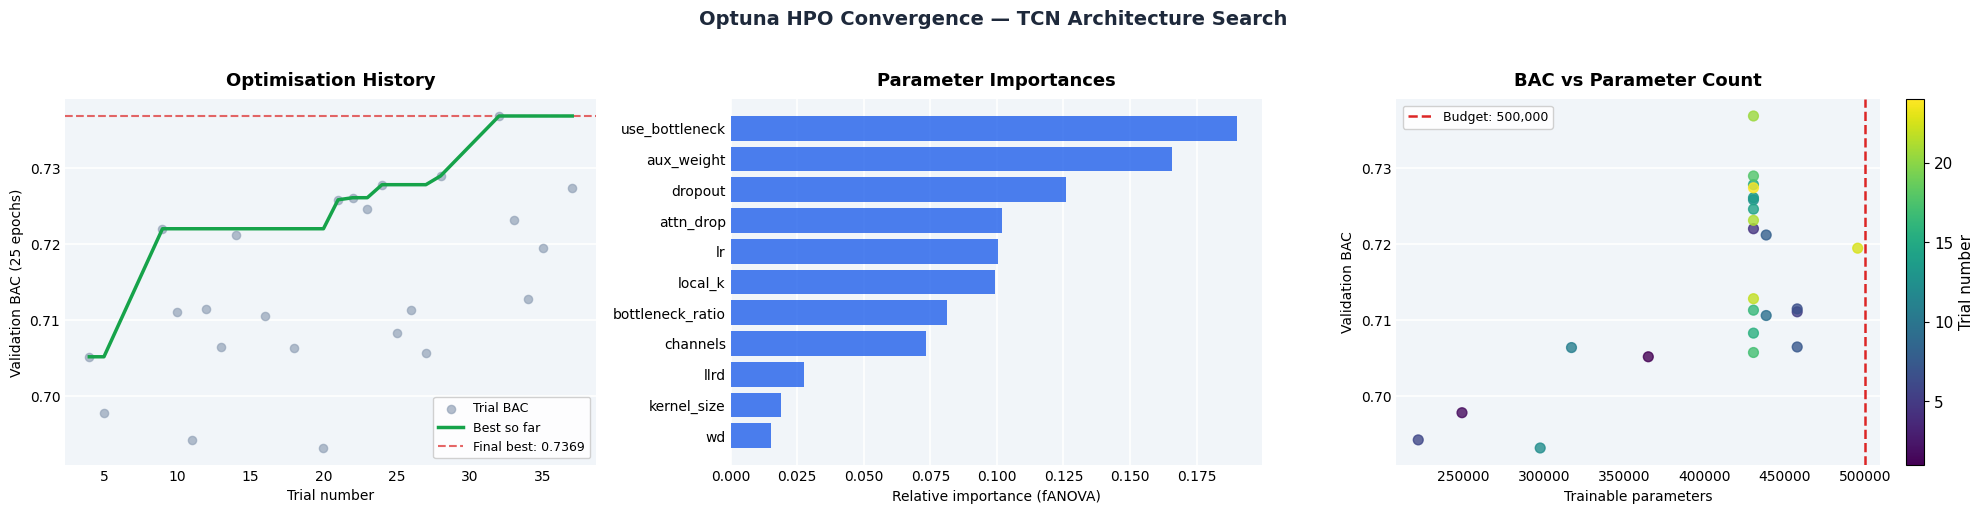

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Optuna HPO Convergence — TCN Architecture Search', fontsize=14,
             fontweight='bold', color='#1E293B', y=1.02)

C_SVM   = '#94A3B8'
C_LSTM  = '#2563EB'
C_TCN   = '#16A34A'
C_RED   = '#DC2626'
C_GOLD  = '#D97706'
C_SLATE = '#1E293B'
C_LGREY = '#F1F5F9'
C_MGREY = '#94A3B8'
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13,
                     'axes.titleweight': 'bold', 'figure.facecolor': 'white'})

# ── Panel 1: optimisation history ────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(C_LGREY)
trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
trial_nums = [t.number + 1 for t in trials]
trial_vals = [t.value for t in trials]
best_so_far_curve = np.maximum.accumulate(trial_vals)
ax.scatter(trial_nums, trial_vals, color=C_MGREY, s=35, zorder=3, alpha=0.7, label='Trial BAC')
ax.plot(trial_nums, best_so_far_curve, color=C_TCN, lw=2.5, zorder=4, label='Best so far')
ax.axhline(best_so_far_curve[-1], color=C_RED, lw=1.5, ls='--', alpha=0.7,
           label=f'Final best: {best_so_far_curve[-1]:.4f}')
ax.set_xlabel('Trial number'); ax.set_ylabel('Validation BAC (25 epochs)')
ax.set_title('Optimisation History', pad=10)
ax.legend(fontsize=9, framealpha=0.9)
ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)

# ── Panel 2: parameter importances (fANOVA) ───────────────────────────────────
ax = axes[1]
ax.set_facecolor(C_LGREY)
try:
    from optuna.importance import get_param_importances
    importances = get_param_importances(study)
    imp_names = list(importances.keys())
    imp_vals  = list(importances.values())
    sorted_idx = np.argsort(imp_vals)
    ax.barh([imp_names[i] for i in sorted_idx], [imp_vals[i] for i in sorted_idx],
            color=C_LSTM, alpha=0.82, zorder=3)
    ax.set_xlabel('Relative importance (fANOVA)')
    ax.set_title('Parameter Importances', pad=10)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.tick_params(length=0)
    ax.xaxis.grid(True, color='white', lw=1.2, zorder=1)
except Exception:
    ax.text(0.5, 0.5, 'fANOVA requires\n≥10 complete trials', ha='center', va='center',
            transform=ax.transAxes, color=C_SLATE, fontsize=11)
    ax.set_title('Parameter Importances', pad=10)

# ── Panel 3: BAC vs param count ───────────────────────────────────────────────
ax = axes[2]
ax.set_facecolor(C_LGREY)
param_counts = [t.user_attrs.get('n_params', 0) for t in trials]
bac_vals     = [t.value for t in trials]
ax.scatter(param_counts, bac_vals, c=trial_nums, cmap='viridis', s=50, zorder=3, alpha=0.8)
ax.axvline(PARAM_BUDGET, color=C_RED, lw=1.8, ls='--', zorder=4, label=f'Budget: {PARAM_BUDGET:,}')
ax.set_xlabel('Trainable parameters')
ax.set_ylabel('Validation BAC')
ax.set_title('BAC vs Parameter Count', pad=10)
ax.legend(fontsize=9, framealpha=0.9)
ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=1, vmax=len(trials)))
plt.colorbar(sm, ax=ax, label='Trial number', fraction=0.04)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['save_dir'], 'fig_optuna_convergence.png'), dpi=150, bbox_inches='tight')
plt.show()


## Updating CONFIG with Best Optuna Hyperparameters

We now lock in the Optuna-found configuration before running the full multi-seed experiment.


In [12]:
best_p = study.best_trial.params
best_channels = CHANNEL_OPTIONS[best_p['channels']]

CONFIG['tcn_channels']         = best_channels
CONFIG['tcn_k']                = best_p['kernel_size']
CONFIG['tcn_drop']             = best_p['dropout']
CONFIG['tcn_lr']               = best_p['lr']
CONFIG['tcn_wd']               = best_p['wd']
CONFIG['tcn_aux_pos_weight']   = best_p['aux_weight']
CONFIG['tcn_local_k']          = best_p['local_k']
CONFIG['tcn_use_bottleneck']   = best_p.get('use_bottleneck', True)
CONFIG['tcn_bottleneck_ratio'] = best_p.get('bottleneck_ratio', 0.5)
CONFIG['tcn_attn_drop']        = best_p.get('attn_drop', CONFIG['tcn_attn_drop'])
CONFIG['tcn_llrd']             = best_p.get('llrd', CONFIG['tcn_llrd'])

_tt_best = TCNClassifier(10, CONFIG['tcn_channels'], CONFIG['tcn_k'],
                          CONFIG['tcn_drop'], CONFIG['tcn_type_embed'],
                          CONFIG['tcn_cond_dim'], local_k=CONFIG['tcn_local_k'],
                          use_bottleneck=CONFIG['tcn_use_bottleneck'],
                          bottleneck_ratio=CONFIG['tcn_bottleneck_ratio'],
                          attn_heads=CONFIG['tcn_attn_heads'],
                          attn_drop=CONFIG['tcn_attn_drop'])
TCN_PARAMS = count_params(_tt_best)
del _tt_best

rf = 1 + 2*(CONFIG['tcn_k']-1)*(2**len(CONFIG['tcn_channels']) - 1)

print("  Locked-in TCN configuration:")
print(f"  {'─'*50}")
print(f"  Channels:         {CONFIG['tcn_channels']}")
print(f"  Kernel size:      {CONFIG['tcn_k']}")
print(f"  Dropout:          {CONFIG['tcn_drop']:.3f}")
print(f"  Learning rate:    {CONFIG['tcn_lr']:.2e}")
print(f"  Weight decay:     {CONFIG['tcn_wd']:.2e}")
print(f"  LLRD:             {CONFIG['tcn_llrd']:.3f}")
print(f"  Aux pos weight:   {CONFIG['tcn_aux_pos_weight']:.3f}")
print(f"  Local pool k:     {CONFIG['tcn_local_k']}")
print(f"  Bottleneck:       {CONFIG['tcn_use_bottleneck']}  (ratio={CONFIG['tcn_bottleneck_ratio']:.3f})")
print(f"  Attn heads/drop:  {CONFIG['tcn_attn_heads']} / {CONFIG['tcn_attn_drop']:.3f}")
print(f"  {'─'*50}")
print(f"  Parameters:       {TCN_PARAMS:,}  / {PARAM_BUDGET:,} budget")
print(f"  Receptive field:  {rf} bins  =  {rf * BIN_SIZE * 1000:.0f} ms")
print(f"  Within budget:    {TCN_PARAMS <= PARAM_BUDGET}")


  Locked-in TCN configuration:
  ──────────────────────────────────────────────────
  Channels:         (64, 80, 96, 112, 128)
  Kernel size:      3
  Dropout:          0.233
  Learning rate:    1.82e-04
  Weight decay:     1.86e-04
  LLRD:             0.829
  Aux pos weight:   0.492
  Local pool k:     5
  Bottleneck:       False  (ratio=0.625)
  Attn heads/drop:  8 / 0.167
  ──────────────────────────────────────────────────
  Parameters:       430,373  / 500,000 budget
  Receptive field:  125 bins  =  2500 ms
  Within budget:    True


## TCN Ablation Study

Before committing to the full multi-seed run, we ablate each major design component of the TCN. Every ablation shares the same data split (seed=42) and trains for 25 epochs, making relative comparisons valid. We remove **one component at a time** from the full model:

| Ablation | What's removed / changed |
|---|---|
| **Full model** | Baseline — all components active |
| **No SE** | Squeeze-and-Excite block replaced with identity |
| **No type gate** | CS-fraction type-embedding set to zero input |
| **No aux task** | Auxiliary position head weight = 0 |
| **No multi-scale pool** | Only global mean pooling (fd = C, not 3C) |
| **No temporal jitter** | Augmentation disabled |
| **No warmup** | Direct cosine decay from epoch 1 |
| **Global mean only** | Replaces triple fusion with single pooling |


In [13]:
def run_ablation(label, channels, k, drop, lr, wd, aux_w, local_k,
                 disable_se=False, disable_type_gate=False, disable_warmup=False,
                 no_augment=False, use_bottleneck=True, bottleneck_ratio=0.5,
                 llrd=0.85, seed=42):
    set_seed(seed)
    tr_ld, va_ld, te_ld = make_loaders_tcn(_X10_opt, _y_opt, _itr_opt, _iva_opt, _ite_opt)
    if no_augment:
        y_pos = LABEL_TO_POSITION[_y_opt]
        tr_ds = LickDataset10(_X10_opt[_itr_opt], _y_opt[_itr_opt], y_pos[_itr_opt], augment=False)
        sampler = _weighted_sampler(_y_opt[_itr_opt]) if CONFIG['use_weighted_sampler'] else None
        tr_ld = DataLoader(tr_ds, CONFIG['batch_size'], sampler=sampler, shuffle=(sampler is None))

    base_model = TCNClassifier(
        10, channels, k, drop, 8, 16, N_CLASSES, local_k,
        use_bottleneck=use_bottleneck,
        bottleneck_ratio=bottleneck_ratio,
        use_se=not disable_se,
        use_type_gate=not disable_type_gate,
        attn_heads=CONFIG['tcn_attn_heads'],
        attn_drop=CONFIG['tcn_attn_drop'],
    ).to(device)
    model = maybe_parallelize_tcn(base_model)

    c7    = nn.CrossEntropyLoss(weight=_cw_opt.to(device), label_smoothing=0.05)
    c_pos = nn.CrossEntropyLoss(weight=_pcw_opt.to(device))
    opt   = AdamW(build_tcn_param_groups(base_model, lr, wd, lr_decay=llrd))

    if disable_warmup:
        sched = CosineAnnealingLR(opt, OPTUNA_EPOCHS, eta_min=1e-5)
    else:
        warmup = LinearLR(opt, start_factor=0.1, end_factor=1.0, total_iters=5)
        cosine = CosineAnnealingLR(opt, OPTUNA_EPOCHS - 5, eta_min=1e-5)
        sched  = SequentialLR(opt, schedulers=[warmup, cosine], milestones=[5])

    best_val, best_state = 0.0, None
    for ep in range(1, OPTUNA_EPOCHS + 1):
        model.train()
        for xb, y7b, ypos in tr_ld:
            xb, y7b, ypos = xb.to(device), y7b.to(device), ypos.to(device)
            lg7, lgp, _   = model(xb)
            loss = c7(lg7, y7b) + aux_w * c_pos(lgp, ypos)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(base_model.parameters(), CONFIG['grad_clip'])
            opt.step()
        sched.step()
        model.eval()
        p_all, l_all = [], []
        with torch.no_grad():
            for xb, y7b, _ in va_ld:
                p_all.extend(model(xb.to(device))[0].argmax(1).cpu().numpy())
                l_all.extend(y7b.numpy())
        bac = balanced_accuracy_score(l_all, p_all)
        if bac > best_val:
            best_val = bac
            best_state = {k_: v.detach().cpu().clone() for k_, v in base_model.state_dict().items()}

    base_model.load_state_dict(best_state)
    model.eval()
    p_all, l_all = [], []
    with torch.no_grad():
        for xb, y7b, _ in te_ld:
            p_all.extend(model(xb.to(device))[0].argmax(1).cpu().numpy())
            l_all.extend(y7b.numpy())
    te_bac = balanced_accuracy_score(l_all, p_all)
    return {'label': label, 'val_bac': best_val, 'test_bac': te_bac, 'n_params': count_params(base_model)}


ch  = CONFIG['tcn_channels']
k_  = CONFIG['tcn_k']
dr  = CONFIG['tcn_drop']
lr_ = CONFIG['tcn_lr']
wd_ = CONFIG['tcn_wd']
aw_ = CONFIG['tcn_aux_pos_weight']
lk_ = CONFIG['tcn_local_k']
btr = CONFIG['tcn_bottleneck_ratio']
llr = CONFIG['tcn_llrd']

ablation_configs = [
    ('Full model (bottleneck)',   dict(use_bottleneck=True, bottleneck_ratio=btr)),
    ('No bottleneck block',       dict(use_bottleneck=False, bottleneck_ratio=1.0)),
    ('Bottleneck ratio = 0.375',  dict(use_bottleneck=True, bottleneck_ratio=0.375)),
    ('Bottleneck ratio = 0.75',   dict(use_bottleneck=True, bottleneck_ratio=0.75)),
    ('No SE block',               dict(disable_se=True)),
    ('No type gate',              dict(disable_type_gate=True)),
    ('No aux task',               dict(aux_w=0.0)),
    ('No temporal jitter',        dict(no_augment=True)),
    ('No warmup scheduler',       dict(disable_warmup=True)),
]

ablation_results = []
print(f"  {'Ablation':<30} {'Val BAC':>9} {'Test BAC':>10} {'Params':>10}")
print(f"  {'─'*68}")
for name, kwargs in ablation_configs:
    kw = dict(
        channels=ch, k=k_, drop=dr, lr=lr_, wd=wd_, aux_w=aw_, local_k=lk_, llrd=llr,
        use_bottleneck=CONFIG['tcn_use_bottleneck'],
        bottleneck_ratio=CONFIG['tcn_bottleneck_ratio'],
    )
    kw.update(kwargs)
    r = run_ablation(name, **kw)
    ablation_results.append(r)
    delta_str = ''
    if name != 'Full model (bottleneck)':
        d = r['test_bac'] - ablation_results[0]['test_bac']
        delta_str = f"  ({d:+.4f})"
    print(f"  {name:<30} {r['val_bac']:>9.4f} {r['test_bac']:>10.4f} {r['n_params']:>10,}{delta_str}")


  Ablation                         Val BAC   Test BAC     Params
  ────────────────────────────────────────────────────────────────────
  Full model (bottleneck)           0.7158     0.7110    280,861
  No bottleneck block               0.7369     0.7134    430,373  (+0.0024)
  Bottleneck ratio = 0.375          0.7142     0.7100    221,885  (-0.0010)
  Bottleneck ratio = 0.75           0.7121     0.7111    317,189  (+0.0001)
  No SE block                       0.7193     0.7109    405,453  (-0.0001)
  No type gate                      0.7188     0.7155    430,373  (+0.0045)
  No aux task                       0.7048     0.7025    430,373  (-0.0085)
  No temporal jitter                0.7182     0.7485    430,373  (+0.0375)
  No warmup scheduler               0.7277     0.7130    430,373  (+0.0020)


## Ablation Visualisation

Each bar shows the test BAC drop (or gain) relative to the full model. Components with large negative deltas are load-bearing — removing them meaningfully hurts performance.


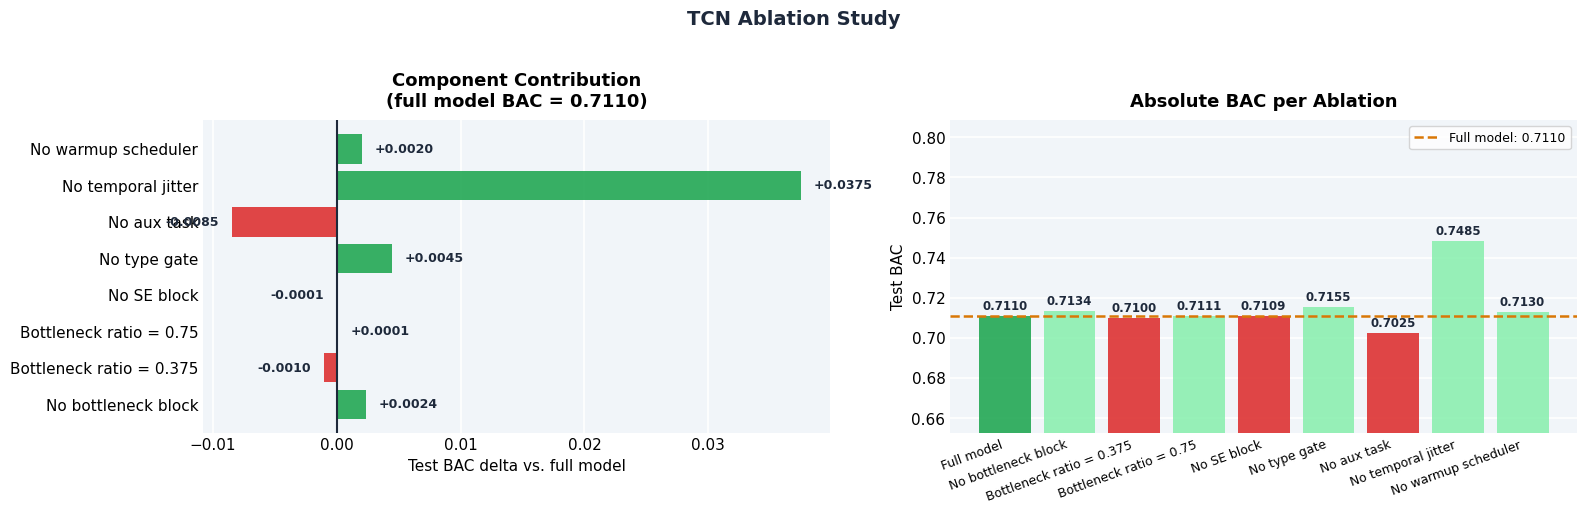

In [14]:
full_bac    = ablation_results[0]['test_bac']
abl_labels  = [r['label'] for r in ablation_results[1:]]
abl_deltas  = [r['test_bac'] - full_bac for r in ablation_results[1:]]
abl_abs     = [r['test_bac'] for r in ablation_results[1:]]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('TCN Ablation Study', fontsize=14, fontweight='bold', color=C_SLATE, y=1.02)

ax = axes[0]
ax.set_facecolor(C_LGREY)
colors = [C_RED if d < 0 else C_TCN for d in abl_deltas]
bars = ax.barh(abl_labels, abl_deltas, color=colors, alpha=0.85, zorder=3)
ax.axvline(0, color=C_SLATE, lw=1.5, zorder=4)
for bar, d in zip(bars, abl_deltas):
    ax.text(d + (0.001 if d >= 0 else -0.001), bar.get_y() + bar.get_height()/2,
            f'{d:+.4f}', va='center', ha='left' if d >= 0 else 'right', fontsize=9,
            fontweight='600', color=C_SLATE)
ax.set_xlabel('Test BAC delta vs. full model')
ax.set_title(f'Component Contribution\n(full model BAC = {full_bac:.4f})', pad=10)
ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.xaxis.grid(True, color='white', lw=1.2, zorder=1)

ax = axes[1]
ax.set_facecolor(C_LGREY)
all_labels = ['Full model'] + abl_labels
all_bacs   = [full_bac] + abl_abs
bar_colors = [C_TCN] + [C_RED if d < 0 else '#86EFAC' for d in abl_deltas]
bars2 = ax.bar(range(len(all_labels)), all_bacs, color=bar_colors, alpha=0.85, zorder=3)
ax.axhline(full_bac, color=C_GOLD, lw=1.8, ls='--', zorder=4,
           label=f'Full model: {full_bac:.4f}')
for bar, v in zip(bars2, all_bacs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.4f}',
            ha='center', fontsize=8.5, fontweight='600', color=C_SLATE)
ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Test BAC')
ax.set_title('Absolute BAC per Ablation', pad=10)
ax.set_ylim(max(0, min(all_bacs) - 0.05), min(1.0, max(all_bacs) + 0.06))
ax.legend(fontsize=9); ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['save_dir'], 'fig_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()


## Per-Seed Training Functions

In [15]:
def train_svm(seed, X9, y, idx_train, idx_test):
    set_seed(seed)
    Xtr = X9[idx_train].reshape(len(idx_train), -1)
    Xte = X9[idx_test ].reshape(len(idx_test),  -1)
    ytr = y[idx_train]; yte = y[idx_test]

    t0  = time.time()
    svm = SVC(kernel='rbf', C=10, gamma='scale',
              class_weight='balanced', random_state=seed)
    svm.fit(Xtr, ytr)
    train_time = time.time() - t0

    t_i = time.time()
    for _ in range(100): svm.predict(Xte[:1])
    inf_ms = (time.time() - t_i) / 100 * 1000

    preds = svm.predict(Xte)
    return {
        'test_bac':    balanced_accuracy_score(yte, preds),
        'test_acc':    (preds == yte).mean(),
        'test_preds':  preds,
        'test_labels': yte,
        'train_time':  train_time,
        'inf_ms':      inf_ms,
        'n_svs':       svm.n_support_.sum(),
    }


@torch.no_grad()
def _eval_lstm(model, loader, criterion):
    model.eval()
    tot_loss = correct = total = 0
    preds_all, labels_all = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        tot_loss += criterion(logits, y).item() * len(y)
        p = logits.argmax(1)
        correct += (p == y).sum().item(); total += len(y)
        preds_all.extend(p.cpu().numpy()); labels_all.extend(y.cpu().numpy())
    bac = balanced_accuracy_score(labels_all, preds_all)
    return tot_loss/total, correct/total, bac, np.array(preds_all), np.array(labels_all)


def train_lstm(seed, X9, y, idx_train, idx_val, idx_test, cw):
    set_seed(seed)
    tr_ld, va_ld, te_ld = make_loaders_lstm(X9, y, idx_train, idx_val, idx_test)

    model = CABiLSTM(9, CONFIG['lstm_hidden'], CONFIG['lstm_layers'],
                     N_CLASSES, CONFIG['lstm_dropout'],
                     CONFIG['lstm_ca_reduction']).to(device)
    crit  = nn.CrossEntropyLoss(
        weight=cw.to(device) if CONFIG['use_class_weights'] else None,
        label_smoothing=0.05)
    opt   = AdamW(model.parameters(), lr=CONFIG['lstm_lr'], weight_decay=CONFIG['lstm_wd'])
    sched = CosineAnnealingLR(opt, CONFIG['epochs'], eta_min=1e-6)

    best_bac, best_ep, best_state = -1., 0, None
    val_hist = []
    t0 = time.time()
    for ep in range(1, CONFIG['epochs']+1):
        model.train()
        for x, yb in tr_ld:
            x, yb = x.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(x), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
            opt.step()
        sched.step()
        _, _, va_bac, _, _ = _eval_lstm(model, va_ld, crit)
        val_hist.append(va_bac)
        if va_bac > best_bac:
            best_bac = va_bac; best_ep = ep
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    train_time = time.time() - t0

    model.load_state_dict(best_state)
    _, te_acc, te_bac, te_preds, te_labels = _eval_lstm(model, te_ld, crit)

    dummy = torch.randn(1, N_BINS, 9).to(device)
    model.eval()
    with torch.no_grad():
        t_i = time.time()
        for _ in range(100): model(dummy)
        inf_ms = (time.time()-t_i)/100*1000

    return {
        'test_bac':     te_bac,
        'test_acc':     te_acc,
        'test_preds':   te_preds,
        'test_labels':  te_labels,
        'best_epoch':   best_ep,
        'train_time':   train_time,
        'inf_ms':       inf_ms,
        'val_bac_hist': val_hist,
    }


def train_tcn(seed, X10, y, idx_train, idx_val, idx_test, cw, pcw):
    set_seed(seed)
    tr_ld, va_ld, te_ld = make_loaders_tcn(X10, y, idx_train, idx_val, idx_test)

    base_model  = TCNClassifier(10, CONFIG['tcn_channels'], CONFIG['tcn_k'],
                                CONFIG['tcn_drop'], CONFIG['tcn_type_embed'],
                                CONFIG['tcn_cond_dim'], N_CLASSES,
                                CONFIG['tcn_local_k'],
                                use_bottleneck=CONFIG['tcn_use_bottleneck'],
                                bottleneck_ratio=CONFIG['tcn_bottleneck_ratio'],
                                attn_heads=CONFIG['tcn_attn_heads'],
                                attn_drop=CONFIG['tcn_attn_drop']).to(device)
    model = maybe_parallelize_tcn(base_model)

    c7     = nn.CrossEntropyLoss(weight=cw.to(device)  if CONFIG['use_class_weights'] else None,
                                 label_smoothing=0.05)
    c_pos  = nn.CrossEntropyLoss(weight=pcw.to(device) if CONFIG['use_class_weights'] else None)
    opt    = AdamW(build_tcn_param_groups(base_model, CONFIG['tcn_lr'], CONFIG['tcn_wd'], lr_decay=CONFIG['tcn_llrd']))
    warmup_sched = LinearLR(opt, start_factor=0.1, end_factor=1.0, total_iters=5)
    cosine_sched = CosineAnnealingLR(opt, CONFIG['epochs'] - 5, eta_min=1e-5)
    sched        = SequentialLR(opt, schedulers=[warmup_sched, cosine_sched], milestones=[5])

    best_bac, best_ep, best_state = -1., 0, None
    val_hist = []
    t0 = time.time()
    for ep in range(1, CONFIG['epochs']+1):
        model.train()
        for xb, y7b, ypos in tr_ld:
            xb, y7b, ypos = xb.to(device), y7b.to(device), ypos.to(device)
            lg7, lgp, _   = model(xb)
            loss = c7(lg7, y7b) + CONFIG['tcn_aux_pos_weight'] * c_pos(lgp, ypos)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(base_model.parameters(), CONFIG['grad_clip'])
            opt.step()
        sched.step()

        model.eval()
        p_all, l_all = [], []
        with torch.no_grad():
            for xb, y7b, _ in va_ld:
                p_all.extend(model(xb.to(device))[0].argmax(1).cpu().numpy())
                l_all.extend(y7b.numpy())
        va_bac = balanced_accuracy_score(l_all, p_all)
        val_hist.append(va_bac)
        if va_bac > best_bac:
            best_bac = va_bac; best_ep = ep
            best_state = {k: v.detach().cpu().clone() for k, v in base_model.state_dict().items()}
    train_time = time.time() - t0

    base_model.load_state_dict(best_state)
    model.eval()
    p_all, l_all = [], []
    with torch.no_grad():
        for xb, y7b, _ in te_ld:
            p_all.extend(model(xb.to(device))[0].argmax(1).cpu().numpy())
            l_all.extend(y7b.numpy())
    te_bac = balanced_accuracy_score(l_all, p_all)
    te_acc = (np.array(p_all)==np.array(l_all)).mean()

    dummy = torch.randn(1, 10, N_BINS).to(device)
    with torch.no_grad():
        t_i = time.time()
        for _ in range(100): model(dummy)
        inf_ms = (time.time()-t_i)/100*1000

    return {
        'test_bac':     te_bac,
        'test_acc':     te_acc,
        'test_preds':   np.array(p_all),
        'test_labels':  np.array(l_all),
        'best_epoch':   best_ep,
        'train_time':   train_time,
        'inf_ms':       inf_ms,
        'val_bac_hist': val_hist,
    }


In [16]:
def train_bigru(seed, X9, y, idx_train, idx_val, idx_test, cw):
    """Train CABiGRU for a single seed — identical protocol to train_lstm."""
    set_seed(seed)
    tr_ld, va_ld, te_ld = make_loaders_lstm(X9, y, idx_train, idx_val, idx_test)

    model = CABiGRU(9, CONFIG['lstm_hidden'], CONFIG['lstm_layers'],
                    N_CLASSES, CONFIG['lstm_dropout'],
                    CONFIG['lstm_ca_reduction']).to(device)
    crit  = nn.CrossEntropyLoss(
        weight=cw.to(device) if CONFIG['use_class_weights'] else None,
        label_smoothing=0.05)
    opt   = AdamW(model.parameters(), lr=CONFIG['lstm_lr'],
                  weight_decay=CONFIG['lstm_wd'])
    sched = CosineAnnealingLR(opt, CONFIG['epochs'], eta_min=1e-6)

    best_bac, best_ep, best_state = -1., 0, None
    val_hist = []
    t0 = time.time()
    for ep in range(1, CONFIG['epochs'] + 1):
        model.train()
        for x, yb in tr_ld:
            x, yb = x.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(x), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
            opt.step()
        sched.step()
        _, _, va_bac, _, _ = _eval_lstm(model, va_ld, crit)
        val_hist.append(va_bac)
        if va_bac > best_bac:
            best_bac  = va_bac
            best_ep   = ep
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
    train_time = time.time() - t0

    model.load_state_dict(best_state)
    _, te_acc, te_bac, te_preds, te_labels = _eval_lstm(model, te_ld, crit)

    dummy = torch.randn(1, N_BINS, 9).to(device)
    model.eval()
    with torch.no_grad():
        t_i = time.time()
        for _ in range(100): model(dummy)
        inf_ms = (time.time() - t_i) / 100 * 1000

    return {
        'test_bac':     te_bac,
        'test_acc':     te_acc,
        'test_preds':   te_preds,
        'test_labels':  te_labels,
        'best_epoch':   best_ep,
        'train_time':   train_time,
        'inf_ms':       inf_ms,
        'val_bac_hist': val_hist,
    }


def train_vit(seed, X9, y, idx_train, idx_val, idx_test, cw):
    """Train MicroViT for a single seed."""
    set_seed(seed)
    tr_ld, va_ld, te_ld = make_loaders_vit(X9, y, idx_train, idx_val, idx_test)

    model = MicroViT(**CONFIG_VIT).to(device)
    crit  = nn.CrossEntropyLoss(
        weight=cw.to(device) if CONFIG['use_class_weights'] else None,
        label_smoothing=0.05)
    opt   = AdamW(model.parameters(), lr=CONFIG['lstm_lr'],
                  weight_decay=CONFIG['lstm_wd'])
    warmup = LinearLR(opt, start_factor=0.1, end_factor=1.0, total_iters=5)
    cosine = CosineAnnealingLR(opt, CONFIG['epochs'] - 5, eta_min=1e-6)
    sched  = SequentialLR(opt, schedulers=[warmup, cosine], milestones=[5])

    best_bac, best_ep, best_state = -1., 0, None
    val_hist = []
    t0 = time.time()
    for ep in range(1, CONFIG['epochs'] + 1):
        model.train()
        for x, yb in tr_ld:
            x, yb = x.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(x), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
            opt.step()
        sched.step()
        _, _, va_bac, _, _ = _eval_lstm(model, va_ld, crit)
        val_hist.append(va_bac)
        if va_bac > best_bac:
            best_bac  = va_bac
            best_ep   = ep
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
    train_time = time.time() - t0

    model.load_state_dict(best_state)
    _, te_acc, te_bac, te_preds, te_labels = _eval_lstm(model, te_ld, crit)

    dummy = torch.randn(1, 9, N_BINS).to(device)
    model.eval()
    with torch.no_grad():
        t_i = time.time()
        for _ in range(100): model(dummy)
        inf_ms = (time.time() - t_i) / 100 * 1000

    return {
        'test_bac':     te_bac,
        'test_acc':     te_acc,
        'test_preds':   te_preds,
        'test_labels':  te_labels,
        'best_epoch':   best_ep,
        'train_time':   train_time,
        'inf_ms':       inf_ms,
        'val_bac_hist': val_hist,
    }


## BiGRU & Micro-ViT — Single-Seed Evaluation (seed = 42)

Both new models are evaluated on the same train/val/test split as seed 42 from the multi-seed experiment above. No multi-seed loop is run for these augmentations.


In [17]:
print("─" * 60)
print("  BiGRU & Micro-ViT  single-seed evaluation  (seed = 42)")
print("─" * 60)

_seed = 42
_X9, _X10, _y, _idx_train, _idx_val, _idx_test, _cw, _pcw = build_arrays(
    MAT_PATHS, seed=_seed)

# Reference: CA-BiLSTM on the same seed (fast re-run to get preds for comparison)
lstm_ref    = train_lstm(_seed, _X9, _y, _idx_train, _idx_val, _idx_test, _cw)
bigru_result = train_bigru(_seed, _X9, _y, _idx_train, _idx_val, _idx_test, _cw)
vit_result   = train_vit(  _seed, _X9, _y, _idx_train, _idx_val, _idx_test, _cw)

# Keep test arrays for attention rollout later
_X9_test = _X9[_idx_test]

del _X9, _X10, _y, _idx_train, _idx_val, _idx_test, _cw, _pcw

print(f"\n  {'Model':<16} {'Test BAC':>10}  {'Test Acc':>10}  "
      f"{'Best Ep':>8}  {'Train(min)':>11}  {'Inf(ms)':>8}")
print(f"  {'─'*72}")
for lbl, r in [('CA-BiLSTM', lstm_ref),
                ('CA-BiGRU',  bigru_result),
                ('Micro-ViT', vit_result)]:
    print(f"  {lbl:<16} {r['test_bac']:>10.4f}  {r['test_acc']:>10.4f}  "
          f"{r['best_epoch']:>8}  {r['train_time']/60:>11.2f}  {r['inf_ms']:>8.3f}")

print(f"\n  Δ BAC vs CA-BiLSTM (seed=42):")
print(f"    CA-BiGRU  : {bigru_result['test_bac'] - lstm_ref['test_bac']:+.4f}")
print(f"    Micro-ViT : {vit_result['test_bac']  - lstm_ref['test_bac']:+.4f}")


────────────────────────────────────────────────────────────
  BiGRU & Micro-ViT  single-seed evaluation  (seed = 42)
────────────────────────────────────────────────────────────
Loading data...
  3 session(s) found in 1D_1.mat
  5 session(s) found in 1D_2.mat
  Split mode: random
  Total: 14,002 licks  —  train: 9,800  |  val: 2,101  |  test: 2,101

  Model              Test BAC    Test Acc   Best Ep   Train(min)   Inf(ms)
  ────────────────────────────────────────────────────────────────────────
  CA-BiLSTM            0.7399      0.4598        15         1.50     0.612
  CA-BiGRU             0.7283      0.4698        34         1.28     0.592
  Micro-ViT            0.7130      0.4650        14         2.42     1.416

  Δ BAC vs CA-BiLSTM (seed=42):
    CA-BiGRU  : -0.0117
    Micro-ViT : -0.0269


## BiGRU & Micro-ViT — Evaluation Plots

Confusion matrices and per-class F1 for all three models on seed 42.


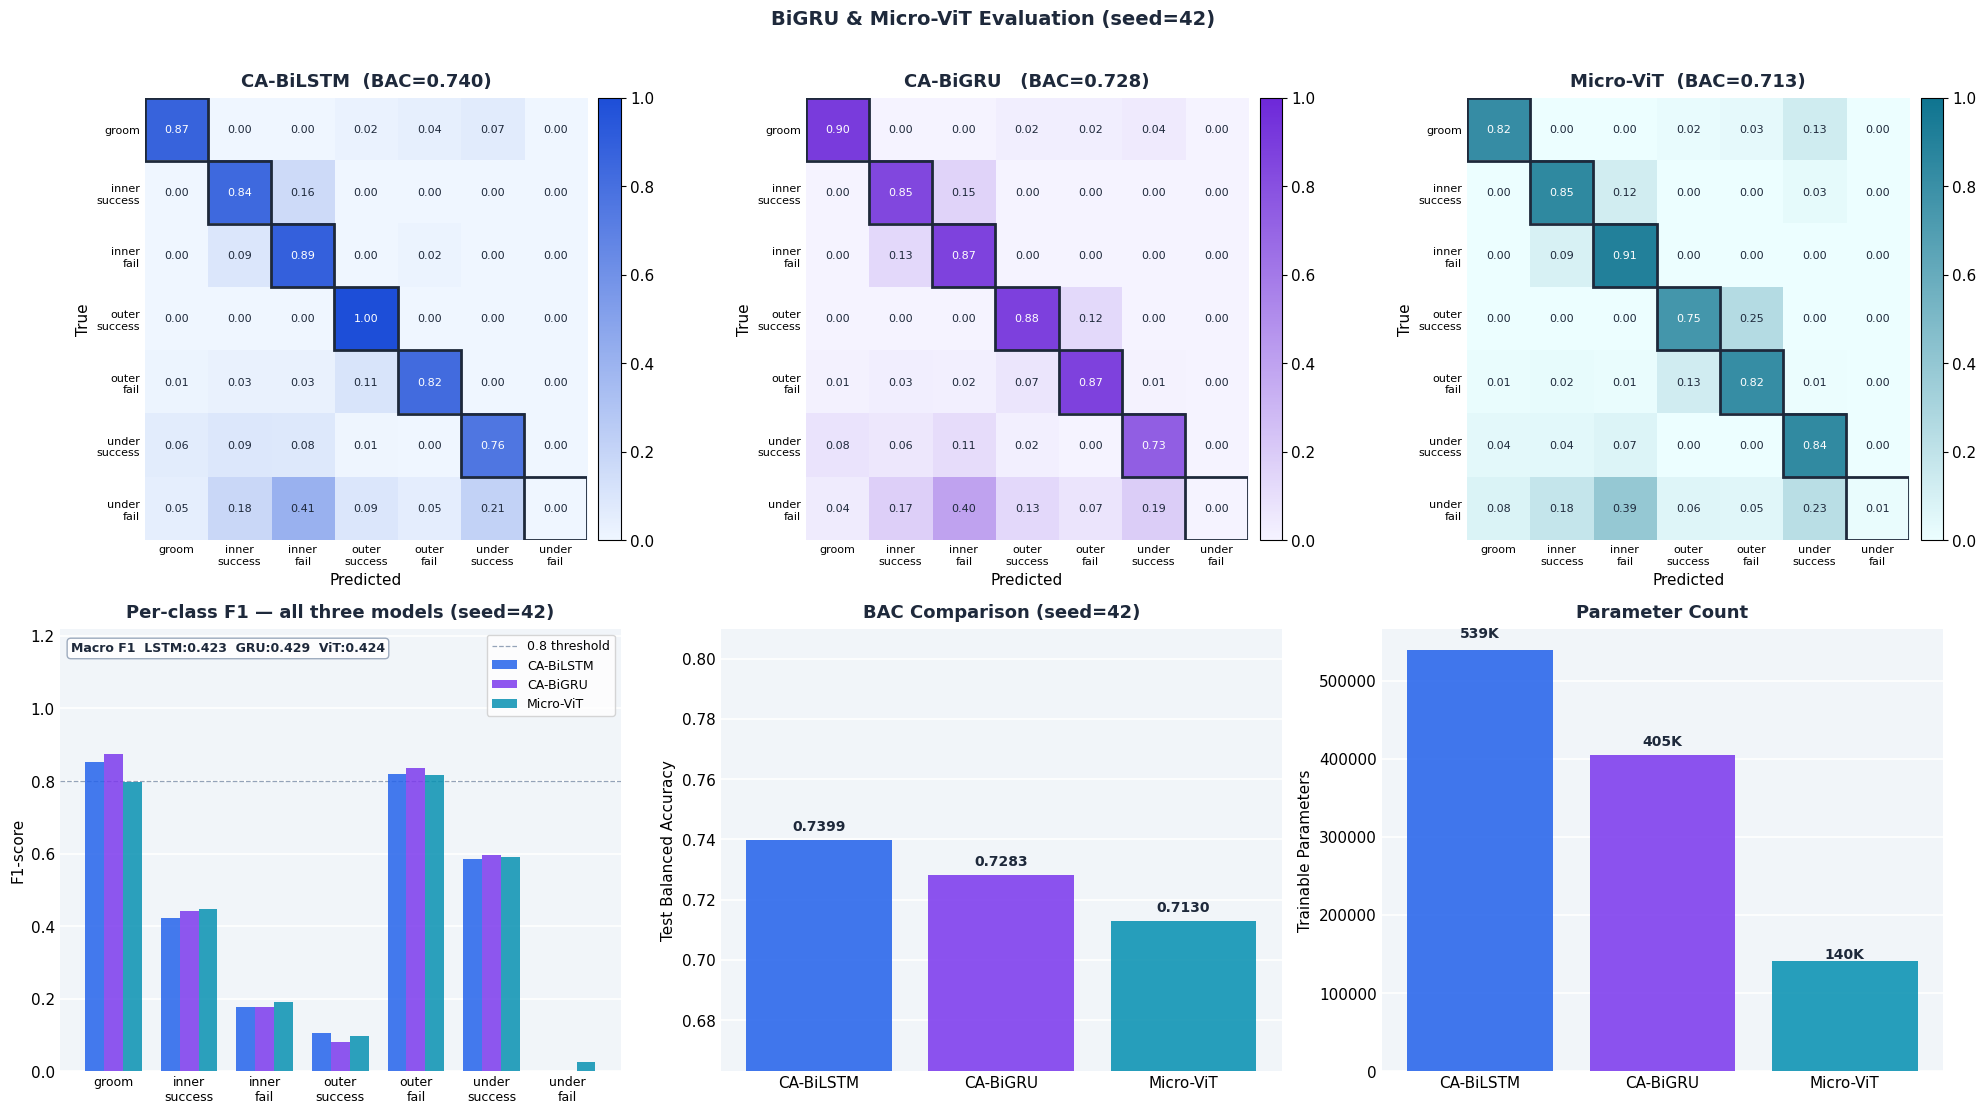

In [18]:
C_VIT   = '#0891B2'   # cyan-600
C_BIGRU = '#7C3AED'   # violet-700

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('BiGRU & Micro-ViT Evaluation (seed=42)',
             fontsize=14, fontweight='bold', color=C_SLATE, y=1.01)

# ── Row 0: confusion matrices ─────────────────────────────────────────────────
conf_specs = [
    (axes[0,0], lstm_ref,     LinearSegmentedColormap.from_list('b',['#EFF6FF','#1D4ED8']),
     f'CA-BiLSTM  (BAC={lstm_ref["test_bac"]:.3f})'),
    (axes[0,1], bigru_result, LinearSegmentedColormap.from_list('v',['#F5F3FF','#6D28D9']),
     f'CA-BiGRU   (BAC={bigru_result["test_bac"]:.3f})'),
    (axes[0,2], vit_result,   LinearSegmentedColormap.from_list('c',['#ECFEFF','#0E7490']),
     f'Micro-ViT  (BAC={vit_result["test_bac"]:.3f})'),
]
for ax, r, cmap, title in conf_specs:
    cm   = confusion_matrix(r['test_labels'], r['test_preds'],
                            labels=list(range(N_CLASSES)))
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    im   = ax.imshow(cm_n, cmap=cmap, vmin=0, vmax=1)
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, f'{cm_n[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, fontweight='500',
                    color='white' if cm_n[i,j] > 0.5 else C_SLATE)
        ax.add_patch(mpatches.Rectangle((i-.5,i-.5), 1, 1, lw=2,
                                         edgecolor=C_SLATE, facecolor='none'))
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(SHORT_NAMES, fontsize=8)
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(SHORT_NAMES, fontsize=8)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title, pad=8, color=C_SLATE)
    ax.tick_params(length=0)
    for sp in ax.spines.values(): sp.set_visible(False)

# ── Row 1, col 0-1: per-class F1 ─────────────────────────────────────────────
_, _, f1_lstm_s,  _ = precision_recall_fscore_support(
    lstm_ref['test_labels'],   lstm_ref['test_preds'],
    labels=list(range(N_CLASSES)), zero_division=0)
_, _, f1_bigru_s, _ = precision_recall_fscore_support(
    bigru_result['test_labels'], bigru_result['test_preds'],
    labels=list(range(N_CLASSES)), zero_division=0)
_, _, f1_vit_s,   _ = precision_recall_fscore_support(
    vit_result['test_labels'],  vit_result['test_preds'],
    labels=list(range(N_CLASSES)), zero_division=0)

ax = axes[1, 0]; ax.set_facecolor(C_LGREY)
x = np.arange(N_CLASSES); w = 0.25
ax.bar(x - w,  f1_lstm_s,  w, label='CA-BiLSTM', color=C_LSTM,   alpha=0.85, zorder=3)
ax.bar(x,      f1_bigru_s, w, label='CA-BiGRU',  color=C_BIGRU,  alpha=0.85, zorder=3)
ax.bar(x + w,  f1_vit_s,   w, label='Micro-ViT', color=C_VIT,    alpha=0.85, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(SHORT_NAMES, fontsize=9)
ax.set_ylim(0, 1.22); ax.set_ylabel('F1-score')
ax.set_title('Per-class F1 — all three models (seed=42)', pad=8, color=C_SLATE)
ax.axhline(0.8, color=C_MGREY, ls='--', lw=0.9, zorder=2, label='0.8 threshold')
ax.text(0.02, 0.97,
        f'Macro F1  LSTM:{f1_lstm_s.mean():.3f}  GRU:{f1_bigru_s.mean():.3f}  ViT:{f1_vit_s.mean():.3f}',
        transform=ax.transAxes, fontsize=9, va='top', color=C_SLATE, fontweight='600',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=C_MGREY, alpha=0.9))
ax.legend(fontsize=9); ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)

# ── Row 1, col 1: BAC bar comparison ─────────────────────────────────────────
ax = axes[1, 1]; ax.set_facecolor(C_LGREY)
mlabels = ['CA-BiLSTM', 'CA-BiGRU', 'Micro-ViT']
bac_vals = [lstm_ref['test_bac'], bigru_result['test_bac'], vit_result['test_bac']]
bar_cols  = [C_LSTM, C_BIGRU, C_VIT]
bars = ax.bar(mlabels, bac_vals, color=bar_cols, alpha=0.87, zorder=3)
for bar, v in zip(bars, bac_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
            f'{v:.4f}', ha='center', fontsize=10, fontweight='600', color=C_SLATE)
ax.set_ylim(max(0, min(bac_vals) - 0.05), min(1.0, max(bac_vals) + 0.07))
ax.set_ylabel('Test Balanced Accuracy')
ax.set_title('BAC Comparison (seed=42)', pad=8, color=C_SLATE)
ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)

# ── Row 1, col 2: param count ─────────────────────────────────────────────────
ax = axes[1, 2]; ax.set_facecolor(C_LGREY)
param_vals = [LSTM_PARAMS, BIGRU_PARAMS, VIT_PARAMS]
bars = ax.bar(mlabels, param_vals, color=bar_cols, alpha=0.87, zorder=3)
for bar, v in zip(bars, param_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v * 1.03,
            f'{v//1000}K', ha='center', fontsize=10, fontweight='600', color=C_SLATE)
ax.set_ylabel('Trainable Parameters')
ax.set_title('Parameter Count', pad=8, color=C_SLATE)
ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['save_dir'], 'fig_bigru_vit_eval.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## Micro-ViT — Attention Rollout Visualisation

Attention rollout aggregates attention from all heads across all layers to produce a single importance map over the 3 patch tokens. We project these scores back onto the **9×30 grid** — specifically onto the time axis — to see which 200 ms temporal segments drive each class prediction.


Loading data...
  3 session(s) found in 1D_1.mat
  5 session(s) found in 1D_2.mat
  Split mode: random
  Total: 14,002 licks  —  train: 9,800  |  val: 2,101  |  test: 2,101


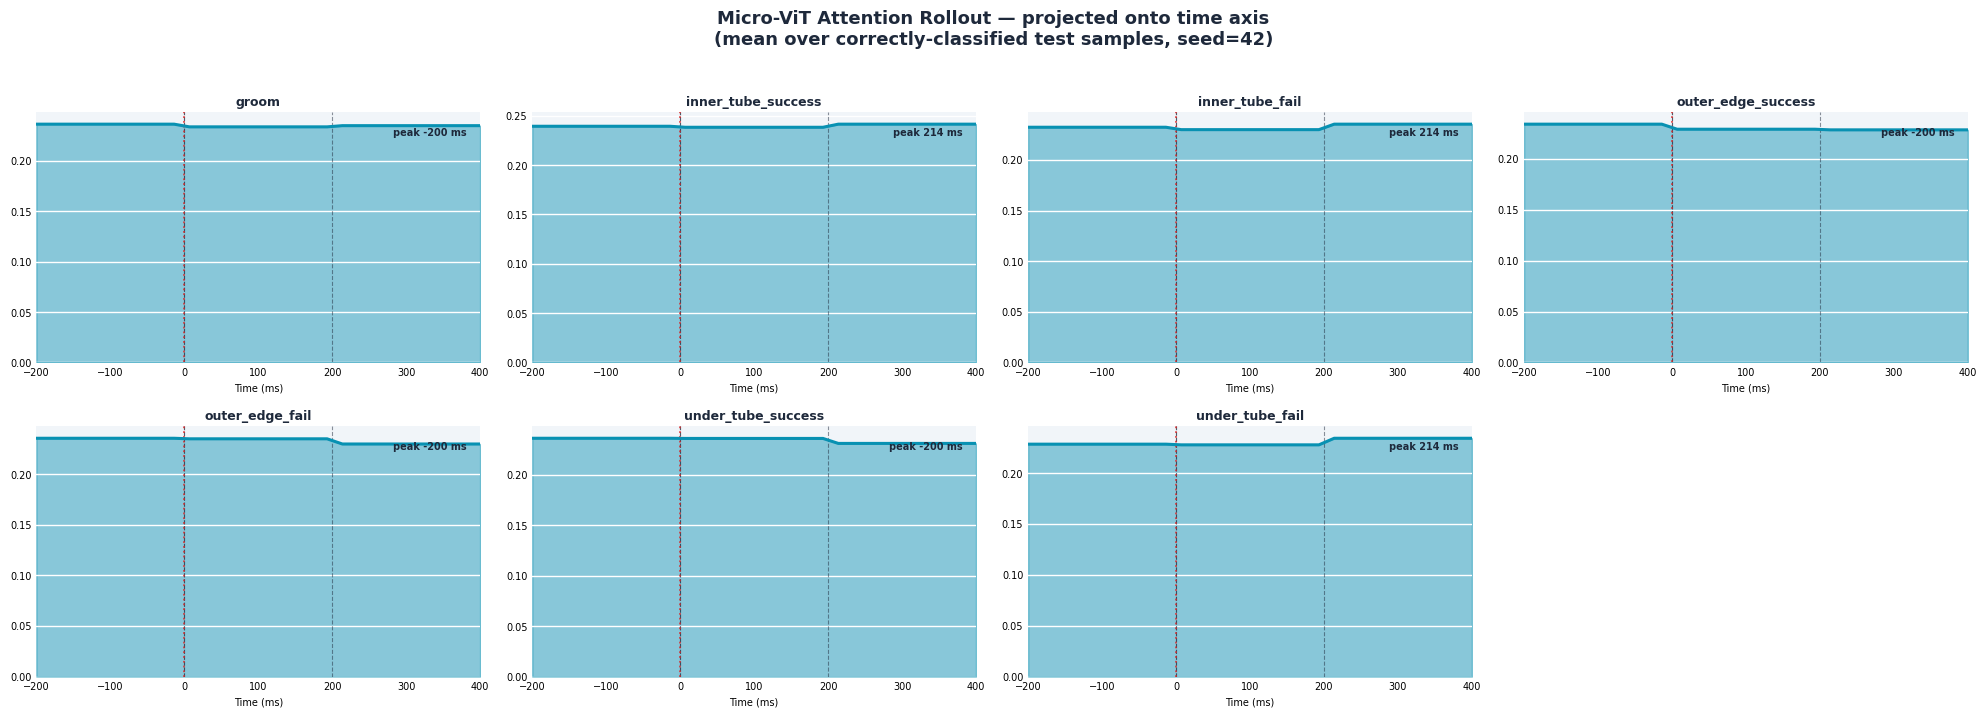

Dashed verticals mark patch boundaries (−200 ms, 0 ms, +200 ms).
Red dotted line = lick onset (t = 0).


In [19]:
def attention_rollout_vit(model, x_image):
    """
    Compute attention rollout for a single image.

    x_image : (1, C=9, T=30) tensor on `device`
    Returns : (4,) numpy array — rollout weights for [CLS, patch0, patch1, patch2]
    """
    model.eval()
    with torch.no_grad():
        B = x_image.shape[0]
        tok = model.patch_embed(x_image)
        cls = model.cls_token.expand(B, -1, -1)
        tok = torch.cat([cls, tok], dim=1) + model.pos_embed
        tok = model.pos_drop(tok)

        attns = []
        h = tok
        for layer in model.transformer.layers:
            h_ln = layer.norm1(h)
            attn_out, attn_w = layer.self_attn(
                h_ln, h_ln, h_ln, need_weights=True, average_attn_weights=True)
            h = h + layer.dropout1(attn_out)
            h = h + layer.dropout2(
                layer.linear2(layer.dropout(
                    layer.activation(layer.linear1(layer.norm2(h))))))
            attns.append(attn_w.squeeze(0).cpu().numpy())  # (seq_len, seq_len)

    # Rollout: A_roll = prod_i (I/2 + A_i/2)
    n = attns[0].shape[0]
    rollout = np.eye(n)
    for A in attns:
        A_aug = 0.5 * A + 0.5 * np.eye(n)
        A_aug = A_aug / A_aug.sum(axis=-1, keepdims=True)
        rollout = rollout @ A_aug
    return rollout[0]   # CLS row: importance of each token


# Build a fresh model with the same weights as vit_result (re-train single seed)
_vit_model = MicroViT(**CONFIG_VIT).to(device)
_vit_crit  = nn.CrossEntropyLoss(
    weight=None, label_smoothing=0.05)

# Lightweight re-train to get state dict (shares the same seed/split as vit_result)
_seed = 42
_X9_tmp, _, _y_tmp, _itr, _iva, _ite, _cw_tmp, _ = build_arrays(MAT_PATHS, seed=_seed)
_vit_r2 = train_vit(_seed, _X9_tmp, _y_tmp, _itr, _iva, _ite, _cw_tmp)
del _X9_tmp, _y_tmp, _itr, _iva, _ite, _cw_tmp

# ── Compute per-class mean attention map (projected to time axis) ─────────────
PATCH_W    = 10    # time bins per patch
N_PATCHES  = 3
time_axis  = np.linspace(-WINDOW_PRE * 1000, WINDOW_POST * 1000, N_BINS)  # ms

class_attns = {}
for cls_id in range(N_CLASSES):
    idxs = np.where(
        (vit_result['test_labels'] == cls_id) &
        (vit_result['test_preds']  == cls_id)
    )[0]
    if len(idxs) == 0:
        class_attns[cls_id] = np.zeros(N_BINS)
        continue
    maps = []
    for i in idxs[:30]:
        img = torch.from_numpy(
            _X9_test[i].T[np.newaxis]).float().to(device)     # (1, 9, 30)
        rollout      = attention_rollout_vit(_vit_model, img)  # (4,)
        patch_scores = rollout[1:]                             # (3,)
        time_map     = np.repeat(patch_scores, PATCH_W)        # (30,)
        maps.append(time_map)
    class_attns[cls_id] = np.mean(maps, axis=0)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 7))
fig.suptitle(
    'Micro-ViT Attention Rollout — projected onto time axis\n'
    '(mean over correctly-classified test samples, seed=42)',
    fontsize=13, fontweight='bold', color=C_SLATE, y=1.02)
axes_flat = axes.flatten()

for cls_id in range(N_CLASSES):
    ax   = axes_flat[cls_id]
    vals = class_attns[cls_id]
    ax.set_facecolor(C_LGREY)
    ax.fill_between(time_axis, vals, alpha=0.45, color=C_VIT)
    ax.plot(time_axis, vals, color=C_VIT, lw=2.2, zorder=3)
    # Patch boundary lines (each patch = 200 ms)
    for boundary_ms in [-200 + WINDOW_PRE*1000, 0, 200]:
        ax.axvline(boundary_ms, color=C_SLATE, lw=0.8, ls='--', alpha=0.5)
    ax.axvline(0, color=C_RED, lw=1.3, ls=':', alpha=0.8, label='lick onset')
    ax.set_title(LABEL_NAMES[cls_id], fontsize=9, pad=5, color=C_SLATE)
    ax.set_xlim(time_axis[0], time_axis[-1])
    ax.set_ylim(0, None)
    ax.tick_params(length=0, labelsize=7)
    ax.set_xlabel('Time (ms)', fontsize=7)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.yaxis.grid(True, color='white', lw=1.0, zorder=1)
    peak_ms = time_axis[np.argmax(vals)] if vals.max() > 0 else 0
    ax.text(0.97, 0.94, f'peak {peak_ms:.0f} ms',
            transform=ax.transAxes, fontsize=7, ha='right', va='top',
            color=C_SLATE, fontweight='600')

axes_flat[N_CLASSES].axis('off')  # unused 8th panel

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['save_dir'], 'fig_vit_attention_rollout.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Dashed verticals mark patch boundaries (−200 ms, 0 ms, +200 ms).")
print("Red dotted line = lick onset (t = 0).")


## Augmentation Summary Table

Numerical summary of both new models (single seed = 42) against the CA-BiLSTM baseline on the same split.


In [20]:
_, _, f1_lstm_s2,  _ = precision_recall_fscore_support(
    lstm_ref['test_labels'],   lstm_ref['test_preds'],
    labels=list(range(N_CLASSES)), zero_division=0)
_, _, f1_bigru_s2, _ = precision_recall_fscore_support(
    bigru_result['test_labels'], bigru_result['test_preds'],
    labels=list(range(N_CLASSES)), zero_division=0)
_, _, f1_vit_s2,   _ = precision_recall_fscore_support(
    vit_result['test_labels'],  vit_result['test_preds'],
    labels=list(range(N_CLASSES)), zero_division=0)

print('\n' + '='*84)
print(f"  Augmentation Summary Table  (seed = 42, same split as multi-seed run)")
print('='*84)
cols   = ['Model', 'Test BAC', 'Test Acc', 'Macro F1', 'Params', 'Train(min)', 'Inf(ms)']
widths = [16, 12, 12, 12, 12, 12, 10]
print(''.join(c.ljust(w) for c, w in zip(cols, widths)))
print('-'*84)
rows = [
    ('CA-BiLSTM', lstm_ref,    LSTM_PARAMS,  f1_lstm_s2.mean()),
    ('CA-BiGRU',  bigru_result, BIGRU_PARAMS, f1_bigru_s2.mean()),
    ('Micro-ViT', vit_result,  VIT_PARAMS,   f1_vit_s2.mean()),
]
for name, r, nparams, macro_f1 in rows:
    vals = [name,
            f"{r['test_bac']:.4f}", f"{r['test_acc']:.4f}",
            f"{macro_f1:.4f}", f"{nparams:,}",
            f"{r['train_time']/60:.2f}", f"{r['inf_ms']:.3f}"]
    print(''.join(v.ljust(w) for v, w in zip(vals, widths)))
print('='*84)
print('\nNotes:')
print('  * Single run — no multi-seed CI for augmentation models.')
print('  * BiGRU: drop-in GRU core; same channel + temporal attention as BiLSTM.')
print('  * Micro-ViT: 3 patches × (9ch × 10bins = 200 ms); self-attention over patches.')



  Augmentation Summary Table  (seed = 42, same split as multi-seed run)
Model           Test BAC    Test Acc    Macro F1    Params      Train(min)  Inf(ms)   
------------------------------------------------------------------------------------
CA-BiLSTM       0.7399      0.4598      0.4229      539,728     1.50        0.612     
CA-BiGRU        0.7283      0.4698      0.4288      405,328     1.28        0.592     
Micro-ViT       0.7130      0.4650      0.4237      140,615     2.42        1.416     

Notes:
  * Single run — no multi-seed CI for augmentation models.
  * BiGRU: drop-in GRU core; same channel + temporal attention as BiLSTM.
  * Micro-ViT: 3 patches × (9ch × 10bins = 200 ms); self-attention over patches.


## Multi-Seed Experiment

All three models are trained on **identical** `(seed, data-split)` pairs, so every BAC comparison is properly paired. This matters for the statistical tests — if each model saw a different data split, differences in BAC could be attributed to data luck rather than architecture.


In [21]:
results = {'svm': [], 'lstm': [], 'tcn': []}

for run_idx, seed in enumerate(SEEDS):
    sep = '─' * 58
    print(f'\n{sep}')
    print(f'  Run {run_idx+1} of {len(SEEDS)}   (seed = {seed})')
    print(f'{sep}')

    X9, X10, y, idx_train, idx_val, idx_test, cw, pcw = build_arrays(MAT_PATHS, seed=seed)

    print('  [1/3]  SVM')
    r = train_svm(seed, X9, y, idx_train, idx_test)
    results['svm'].append(r)
    print(f'         BAC = {r["test_bac"]:.4f}   time = {r["train_time"]:.1f}s   SVs = {r["n_svs"]}')

    print('  [2/3]  CA-BiLSTM')
    r = train_lstm(seed, X9, y, idx_train, idx_val, idx_test, cw)
    results['lstm'].append(r)
    print(f'         BAC = {r["test_bac"]:.4f}   best epoch = {r["best_epoch"]}   time = {r["train_time"]/60:.1f} min')

    print('  [3/3]  TCN')
    r = train_tcn(seed, X10, y, idx_train, idx_val, idx_test, cw, pcw)
    results['tcn'].append(r)
    print(f'         BAC = {r["test_bac"]:.4f}   best epoch = {r["best_epoch"]}   time = {r["train_time"]/60:.1f} min')

np.save(os.path.join(CONFIG['save_dir'], 'multi_seed_results.npy'), results, allow_pickle=True)
print('\n  All runs complete.')



──────────────────────────────────────────────────────────
  Run 1 of 5   (seed = 42)
──────────────────────────────────────────────────────────
Loading data...
  3 session(s) found in 1D_1.mat
  5 session(s) found in 1D_2.mat
  Split mode: random
  Total: 14,002 licks  —  train: 9,800  |  val: 2,101  |  test: 2,101
  [1/3]  SVM
         BAC = 0.6266   time = 10.6s   SVs = 6956
  [2/3]  CA-BiLSTM
         BAC = 0.7399   best epoch = 15   time = 1.5 min
  [3/3]  TCN
         BAC = 0.6971   best epoch = 12   time = 4.6 min

──────────────────────────────────────────────────────────
  Run 2 of 5   (seed = 7)
──────────────────────────────────────────────────────────
Loading data...
  3 session(s) found in 1D_1.mat
  5 session(s) found in 1D_2.mat
  Split mode: random
  Total: 14,002 licks  —  train: 9,800  |  val: 2,101  |  test: 2,101
  [1/3]  SVM
         BAC = 0.6047   time = 10.0s   SVs = 6905
  [2/3]  CA-BiLSTM
         BAC = 0.7553   best epoch = 23   time = 1.5 min
  [3/3]  TCN
  

## Summary Statistics

In [22]:
svm_bacs   = np.array([r['test_bac'] for r in results['svm']])
lstm_bacs  = np.array([r['test_bac'] for r in results['lstm']])
tcn_bacs   = np.array([r['test_bac'] for r in results['tcn']])

svm_times  = np.array([r['train_time'] for r in results['svm']])
lstm_times = np.array([r['train_time'] for r in results['lstm']])
tcn_times  = np.array([r['train_time'] for r in results['tcn']])

svm_inf    = np.array([r['inf_ms'] for r in results['svm']])
lstm_inf   = np.array([r['inf_ms'] for r in results['lstm']])
tcn_inf    = np.array([r['inf_ms'] for r in results['tcn']])

lstm_best_eps = np.array([r['best_epoch'] for r in results['lstm']])
tcn_best_eps  = np.array([r['best_epoch'] for r in results['tcn']])

w = [14, 10, 9, 9, 9, 10, 9]
hdr = (f"{'Model':<{w[0]}} {'BAC mean':>{w[1]}} {'BAC std':>{w[2]}} "
       f"{'BAC min':>{w[3]}} {'BAC max':>{w[4]}} {'Train(s)':>{w[5]}} {'Inf(ms)':>{w[6]}}")
sep = '─' * len(hdr)
print(sep); print(hdr); print(sep)
for nm, bacs, times, infs in [
    ('SVM',       svm_bacs,  svm_times,  svm_inf),
    ('CA-BiLSTM', lstm_bacs, lstm_times, lstm_inf),
    ('TCN',       tcn_bacs,  tcn_times,  tcn_inf),
]:
    print(f"{nm:<{w[0]}} {bacs.mean():>{w[1]}.4f} {bacs.std():>{w[2]}.4f} "
          f"{bacs.min():>{w[3]}.4f} {bacs.max():>{w[4]}.4f} "
          f"{times.mean():>{w[5]}.1f} {infs.mean():>{w[6]}.3f}")
print(sep)
print(f"\n  Best convergence epoch:")
print(f"    CA-BiLSTM : {lstm_best_eps.mean():.1f} ± {lstm_best_eps.std():.1f}")
print(f"    TCN       : {tcn_best_eps.mean():.1f}  ± {tcn_best_eps.std():.1f}")
print(f"\n  Trainable parameters:")
print(f"    SVM       : N/A  (kernel machine)")
print(f"    CA-BiLSTM : {LSTM_PARAMS:,}")
print(f"    TCN       : {TCN_PARAMS:,}  ({TCN_PARAMS/LSTM_PARAMS:.2f}× LSTM)")


────────────────────────────────────────────────────────────────────────────
Model            BAC mean   BAC std   BAC min   BAC max   Train(s)   Inf(ms)
────────────────────────────────────────────────────────────────────────────
SVM                0.6113    0.0172    0.5857    0.6338        9.9     2.369
CA-BiLSTM          0.7200    0.0260    0.6835    0.7553       91.6     0.652
TCN                0.7114    0.0150    0.6971    0.7385      270.4     4.835
────────────────────────────────────────────────────────────────────────────

  Best convergence epoch:
    CA-BiLSTM : 26.8 ± 15.1
    TCN       : 23.2  ± 10.6

  Trainable parameters:
    SVM       : N/A  (kernel machine)
    CA-BiLSTM : 539,728
    TCN       : 430,373  (0.80× LSTM)


## Statistical Tests

**Primary question:** Is the TCN significantly better than the CA-BiLSTM in test BAC?

Since n = 5 (one value per seed/split), we run three complementary tests:

1. **Paired one-sided t-test** — H₀: μ(TCN − LSTM) = 0 vs H₁: μ > 0. Valid under normality; paired structure removes between-split variance.  
2. **Wilcoxon signed-rank test** — non-parametric alternative, sensitive to sign and magnitude of differences.  
3. **Bootstrap 95% CI** on the mean paired difference — no distributional assumption, 10,000 resamples.


In [23]:
diff = tcn_bacs - lstm_bacs

t_stat, p_two = stats.ttest_rel(tcn_bacs, lstm_bacs)
p_one = p_two/2 if t_stat >= 0 else 1 - p_two/2

print('  Paired one-sided t-test  (H₁: TCN > LSTM)')
print(f'  t = {t_stat:.4f}   p (one-sided) = {p_one:.4f}')
if   p_one < 0.05: print('  → Reject H₀ (p < 0.05): TCN is significantly better.')
elif p_one < 0.10: print('  → Marginal evidence for TCN being better (0.05 ≤ p < 0.10).')
else:              print('  → Fail to reject H₀: cannot conclude TCN is better.')

if len(diff) >= 5:
    w_stat, w_p = stats.wilcoxon(tcn_bacs, lstm_bacs, alternative='greater')
    print(f'\n  Wilcoxon signed-rank test  (H₁: TCN > LSTM)')
    print(f'  W = {w_stat}   p (one-sided) = {w_p:.4f}')
    if w_p < 0.05: print('  → TCN significantly better (Wilcoxon, p < 0.05).')
    else:          print('  → Cannot conclude TCN is better (Wilcoxon).')

N_BOOT = 10_000
rng    = np.random.default_rng(0)
boot_means = np.array([
    rng.choice(diff, size=len(diff), replace=True).mean()
    for _ in range(N_BOOT)
])
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print(f'\n  Bootstrap 95% CI  —  mean(TCN − LSTM)')
print(f'  Observed mean Δ : {diff.mean():+.4f}')
print(f'  95% CI          : [{ci_low:+.4f},  {ci_high:+.4f}]')
if   ci_low  > 0: print('  → Entire CI above 0: TCN robustly better.')
elif ci_high < 0: print('  → Entire CI below 0: LSTM robustly better.')
else:             print('  → CI straddles 0: difference is not conclusive.')

print('\n  Supplementary pairwise tests:')
for (nm, a, b) in [('LSTM > SVM', lstm_bacs, svm_bacs),
                   ('TCN  > SVM', tcn_bacs,  svm_bacs)]:
    t_, p_ = stats.ttest_rel(a, b)
    p_o = p_/2 if t_>=0 else 1-p_/2
    print(f'    {nm}: t = {t_:.3f}   p (one-sided) = {p_o:.4f}')


  Paired one-sided t-test  (H₁: TCN > LSTM)
  t = -0.6822   p (one-sided) = 0.7337
  → Fail to reject H₀: cannot conclude TCN is better.

  Wilcoxon signed-rank test  (H₁: TCN > LSTM)
  W = 5.0   p (one-sided) = 0.7812
  → Cannot conclude TCN is better (Wilcoxon).

  Bootstrap 95% CI  —  mean(TCN − LSTM)
  Observed mean Δ : -0.0086
  95% CI          : [-0.0288,  +0.0140]
  → CI straddles 0: difference is not conclusive.

  Supplementary pairwise tests:
    LSTM > SVM: t = 6.724   p (one-sided) = 0.0013
    TCN  > SVM: t = 7.578   p (one-sided) = 0.0008


## Visualisations

In [24]:
C_SVM   = '#94A3B8'
C_LSTM  = '#2563EB'
C_TCN   = '#16A34A'
C_RED   = '#DC2626'
C_GOLD  = '#D97706'
C_SLATE = '#1E293B'
C_LGREY = '#F1F5F9'
C_MGREY = '#94A3B8'
SDIR    = CONFIG['save_dir']

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13,
                     'axes.titleweight': 'bold', 'figure.facecolor': 'white'})


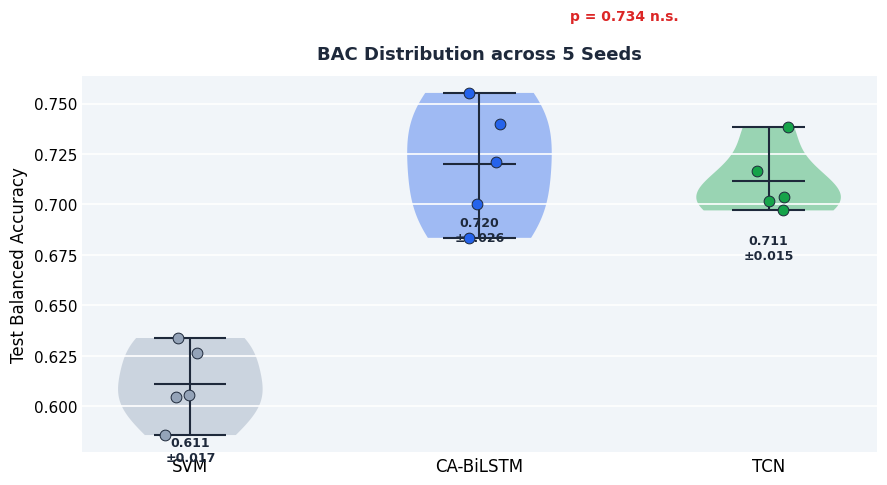

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_facecolor(C_LGREY)

all_data  = [svm_bacs, lstm_bacs, tcn_bacs]
colors    = [C_SVM, C_LSTM, C_TCN]
positions = [1, 2, 3]
mnames    = ['SVM', 'CA-BiLSTM', 'TCN']

vp = ax.violinplot(all_data, positions=positions, widths=0.5,
                   showmeans=True, showmedians=False, showextrema=True)
for pc, c in zip(vp['bodies'], colors):
    pc.set_facecolor(c); pc.set_alpha(0.4)
for part in ['cmeans','cmins','cmaxes','cbars']:
    if part in vp: vp[part].set_color(C_SLATE); vp[part].set_linewidth(1.5)

rng_j = np.random.default_rng(7)
jitter = (rng_j.random((len(SEEDS), 3))-0.5)*0.18
for i, (d, c) in enumerate(zip(all_data, colors)):
    ax.scatter(np.full(len(d), positions[i]) + jitter[:,i], d,
               color=c, s=60, zorder=4, edgecolors=C_SLATE, linewidths=0.7)
    ax.text(positions[i], d.mean()-0.026,
            f'{d.mean():.3f}\n±{d.std():.3f}',
            ha='center', va='top', fontsize=9, color=C_SLATE, fontweight='600')

ax.set_xticks(positions); ax.set_xticklabels(mnames, fontsize=12)
ax.set_ylabel('Test Balanced Accuracy', fontsize=12)
ax.set_title(f'BAC Distribution across {len(SEEDS)} Seeds', pad=12, color=C_SLATE)
ax.yaxis.grid(True, color='white', linewidth=1.2, zorder=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.tick_params(length=0)

ymax = max(max(d) for d in all_data)
yb   = ymax + 0.03
ax.annotate('', xy=(3, yb), xytext=(2, yb),
            arrowprops=dict(arrowstyle='-', color=C_RED, lw=1.8))
lbl = f'p = {p_one:.3f}' + (' *' if p_one<0.05 else ' n.s.')
ax.text(2.5, yb+0.006, lbl, ha='center', color=C_RED, fontsize=10, fontweight='600')

plt.tight_layout()
plt.savefig(os.path.join(SDIR, 'fig1_bac_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()


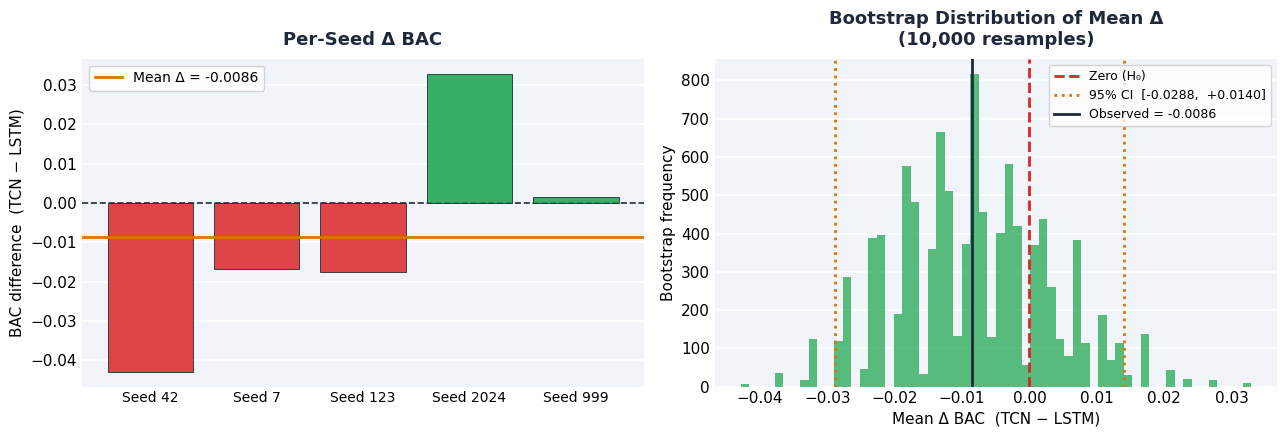

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]; ax.set_facecolor(C_LGREY)
ax.bar(range(len(diff)), diff, color=[C_TCN if d>=0 else C_RED for d in diff],
       alpha=0.85, zorder=3, edgecolor=C_SLATE, linewidth=0.7)
ax.axhline(0, color=C_SLATE, lw=1.2, ls='--', zorder=2)
ax.axhline(diff.mean(), color=C_GOLD, lw=2, ls='-', zorder=4, label=f'Mean Δ = {diff.mean():+.4f}')
ax.set_xticks(range(len(SEEDS))); ax.set_xticklabels([f'Seed {s}' for s in SEEDS], fontsize=10)
ax.set_ylabel('BAC difference  (TCN − LSTM)'); ax.set_title('Per-Seed Δ BAC', pad=10, color=C_SLATE)
ax.legend(fontsize=10); ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)

ax = axes[1]; ax.set_facecolor(C_LGREY)
ax.hist(boot_means, bins=60, color=C_TCN, alpha=0.7, edgecolor='none', zorder=3)
ax.axvline(0,           color=C_RED,   lw=2, ls='--', zorder=4, label='Zero (H₀)')
ax.axvline(ci_low,      color=C_GOLD,  lw=2, ls=':',  zorder=4,
           label=f'95% CI  [{ci_low:+.4f},  {ci_high:+.4f}]')
ax.axvline(ci_high,     color=C_GOLD,  lw=2, ls=':',  zorder=4)
ax.axvline(diff.mean(), color=C_SLATE, lw=2, ls='-',  zorder=5,
           label=f'Observed = {diff.mean():+.4f}')
ax.set_xlabel('Mean Δ BAC  (TCN − LSTM)'); ax.set_ylabel('Bootstrap frequency')
ax.set_title('Bootstrap Distribution of Mean Δ\n(10,000 resamples)', pad=10, color=C_SLATE)
ax.legend(fontsize=9); ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)

plt.tight_layout()
plt.savefig(os.path.join(SDIR, 'fig2_bootstrap_ci.png'), dpi=150, bbox_inches='tight')
plt.show()


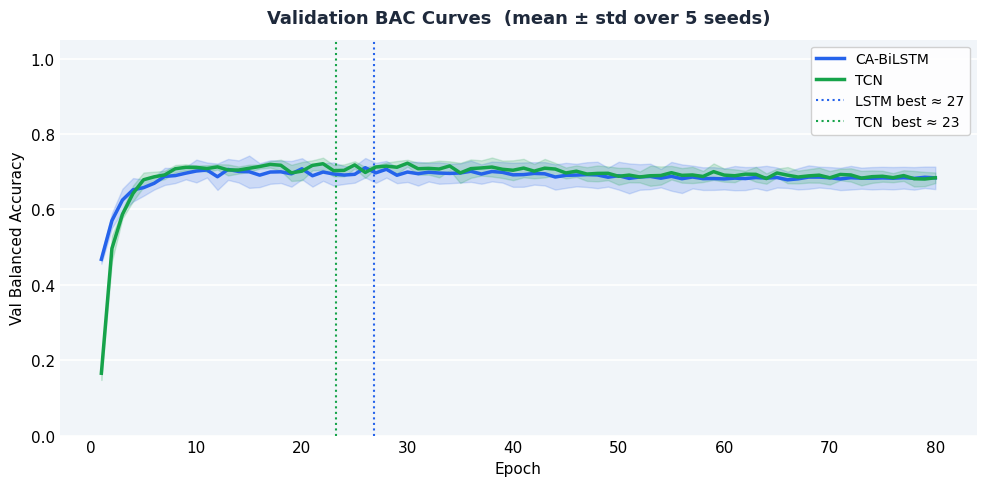

In [27]:
def avg_curves(res_list):
    arr = np.array([r['val_bac_hist'] for r in res_list])
    return arr.mean(0), arr.std(0)

lm, ls = avg_curves(results['lstm'])
tm, ts = avg_curves(results['tcn'])
eps    = np.arange(1, CONFIG['epochs']+1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor(C_LGREY)
for m, s, c, lbl in [(lm, ls, C_LSTM, 'CA-BiLSTM'), (tm, ts, C_TCN, 'TCN')]:
    ax.plot(eps, m, color=c, lw=2.5, label=lbl, zorder=3)
    ax.fill_between(eps, m-s, m+s, color=c, alpha=0.18, zorder=2)
ax.axvline(lstm_best_eps.mean(), color=C_LSTM, ls=':', lw=1.5,
           label=f'LSTM best ≈ {lstm_best_eps.mean():.0f}')
ax.axvline(tcn_best_eps.mean(),  color=C_TCN,  ls=':', lw=1.5,
           label=f'TCN  best ≈ {tcn_best_eps.mean():.0f}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Balanced Accuracy')
ax.set_title(f'Validation BAC Curves  (mean ± std over {len(SEEDS)} seeds)', pad=12, color=C_SLATE)
ax.set_ylim(0, 1.05); ax.legend(fontsize=10, framealpha=0.9); ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)
plt.tight_layout()
plt.savefig(os.path.join(SDIR, 'fig3_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


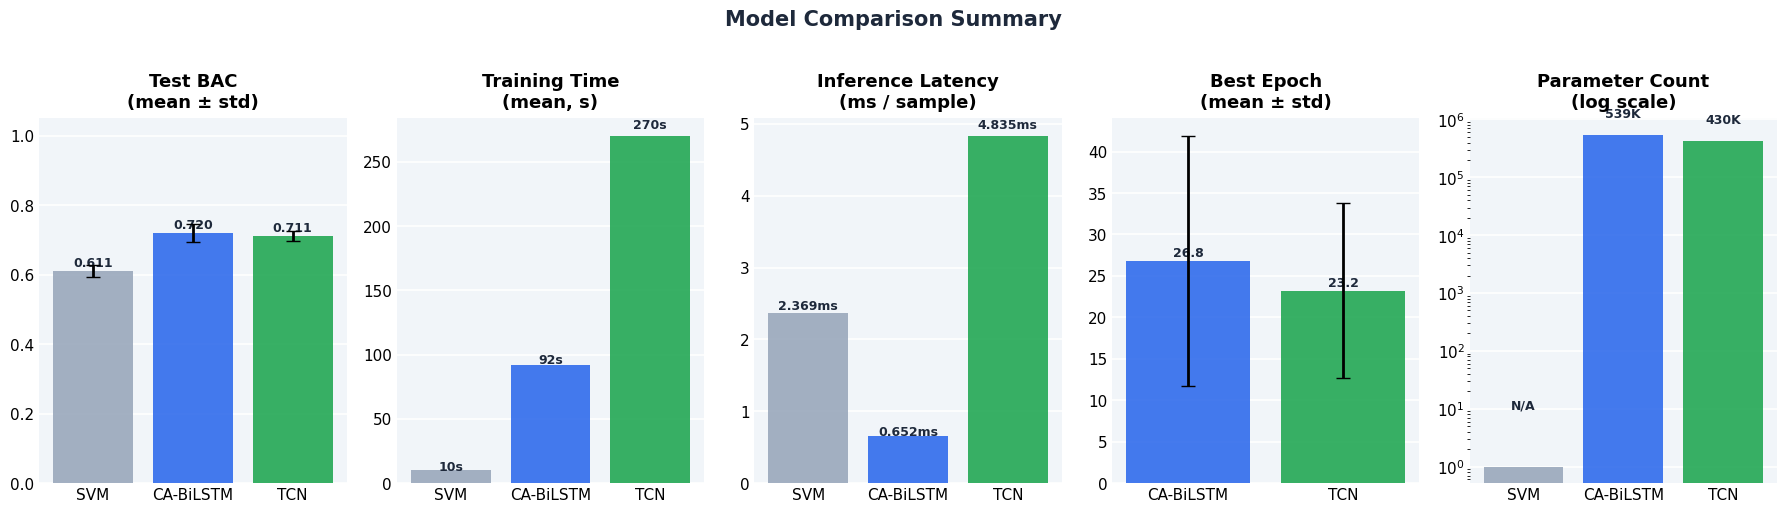

In [28]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Model Comparison Summary', fontsize=15, fontweight='700', color=C_SLATE, y=1.02)

mlabels = ['SVM', 'CA-BiLSTM', 'TCN']
bcs     = [C_SVM, C_LSTM, C_TCN]

def _bar_ax(ax, labels, vals, title, fmt='{:.3f}', yerr=None, colors=None):
    ax.set_facecolor(C_LGREY)
    if colors is None: colors = bcs[:len(labels)]
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, zorder=3,
                  yerr=yerr, capsize=5, error_kw={'lw': 2})
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                fmt.format(v), ha='center', fontsize=9, fontweight='600', color=C_SLATE)
    ax.set_title(title, pad=8); ax.tick_params(length=0)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)

_bar_ax(axes[0], mlabels,
        [svm_bacs.mean(), lstm_bacs.mean(), tcn_bacs.mean()],
        'Test BAC\n(mean ± std)', '{:.3f}',
        yerr=[svm_bacs.std(), lstm_bacs.std(), tcn_bacs.std()])
axes[0].set_ylim(0, 1.05)

_bar_ax(axes[1], mlabels,
        [svm_times.mean(), lstm_times.mean(), tcn_times.mean()],
        'Training Time\n(mean, s)', '{:.0f}s')

_bar_ax(axes[2], mlabels,
        [svm_inf.mean(), lstm_inf.mean(), tcn_inf.mean()],
        'Inference Latency\n(ms / sample)', '{:.3f}ms')

_bar_ax(axes[3], ['CA-BiLSTM', 'TCN'],
        [lstm_best_eps.mean(), tcn_best_eps.mean()],
        'Best Epoch\n(mean ± std)', '{:.1f}',
        yerr=[lstm_best_eps.std(), tcn_best_eps.std()],
        colors=[C_LSTM, C_TCN])

ax = axes[4]; ax.set_facecolor(C_LGREY)
pvals = [1, LSTM_PARAMS, TCN_PARAMS]
ax.bar(mlabels, pvals, color=bcs, alpha=0.85, zorder=3)
ax.set_yscale('log')
for i, (lbl, v) in enumerate(zip(['N/A', f'{LSTM_PARAMS//1000}K', f'{TCN_PARAMS//1000}K'], pvals)):
    ax.text(i, max(v*2, 10), lbl, ha='center', fontsize=9, fontweight='600', color=C_SLATE)
ax.set_title('Parameter Count\n(log scale)', pad=8); ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)

plt.tight_layout()
plt.savefig(os.path.join(SDIR, 'fig4_comparison_bars.png'), dpi=150, bbox_inches='tight')
plt.show()


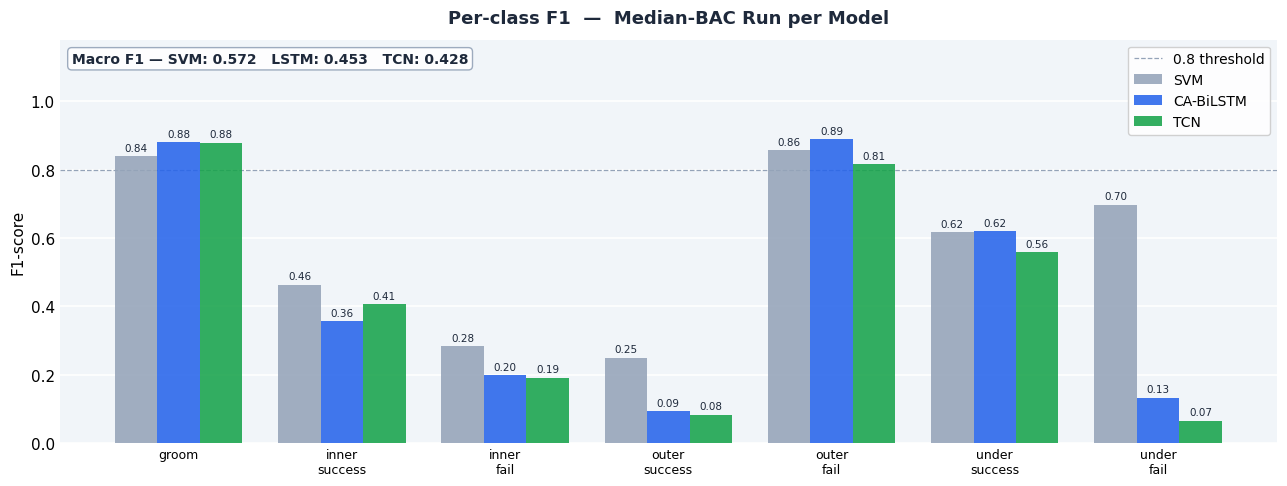

In [29]:
def pick_median(bacs, res):
    return res[np.argsort(bacs)[len(bacs)//2]]

def per_class_f1(r):
    _, _, f1, _ = precision_recall_fscore_support(
        r['test_labels'], r['test_preds'], labels=list(range(N_CLASSES)), zero_division=0)
    return f1

f1_svm  = per_class_f1(pick_median(svm_bacs,  results['svm']))
f1_lstm = per_class_f1(pick_median(lstm_bacs, results['lstm']))
f1_tcn  = per_class_f1(pick_median(tcn_bacs,  results['tcn']))

x = np.arange(N_CLASSES); w = 0.26
fig, ax = plt.subplots(figsize=(13, 5))
ax.set_facecolor(C_LGREY)
for xi, (f1, c, lbl) in enumerate([(f1_svm, C_SVM, 'SVM'), (f1_lstm, C_LSTM, 'CA-BiLSTM'), (f1_tcn, C_TCN, 'TCN')]):
    bars = ax.bar(x+(xi-1)*w, f1, w, label=lbl, color=c, alpha=0.87, zorder=3)
    for bar in bars:
        h = bar.get_height()
        if h > 0.04:
            ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.2f}',
                    ha='center', va='bottom', fontsize=7.5, color=C_SLATE)
ax.set_xticks(x); ax.set_xticklabels(SHORT_NAMES, fontsize=9)
ax.set_ylim(0, 1.18); ax.set_ylabel('F1-score')
ax.set_title('Per-class F1  —  Median-BAC Run per Model', pad=12, color=C_SLATE)
ax.axhline(0.8, color=C_MGREY, ls='--', lw=0.9, zorder=2, label='0.8 threshold')
ax.legend(fontsize=10, framealpha=0.9); ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)
ax.text(0.01, 0.97,
        f'Macro F1 — SVM: {f1_svm.mean():.3f}   LSTM: {f1_lstm.mean():.3f}   TCN: {f1_tcn.mean():.3f}',
        transform=ax.transAxes, fontsize=10, color=C_SLATE, va='top', fontweight='600',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=C_MGREY, alpha=0.9))
plt.tight_layout()
plt.savefig(os.path.join(SDIR, 'fig5_per_class_f1.png'), dpi=150, bbox_inches='tight')
plt.show()


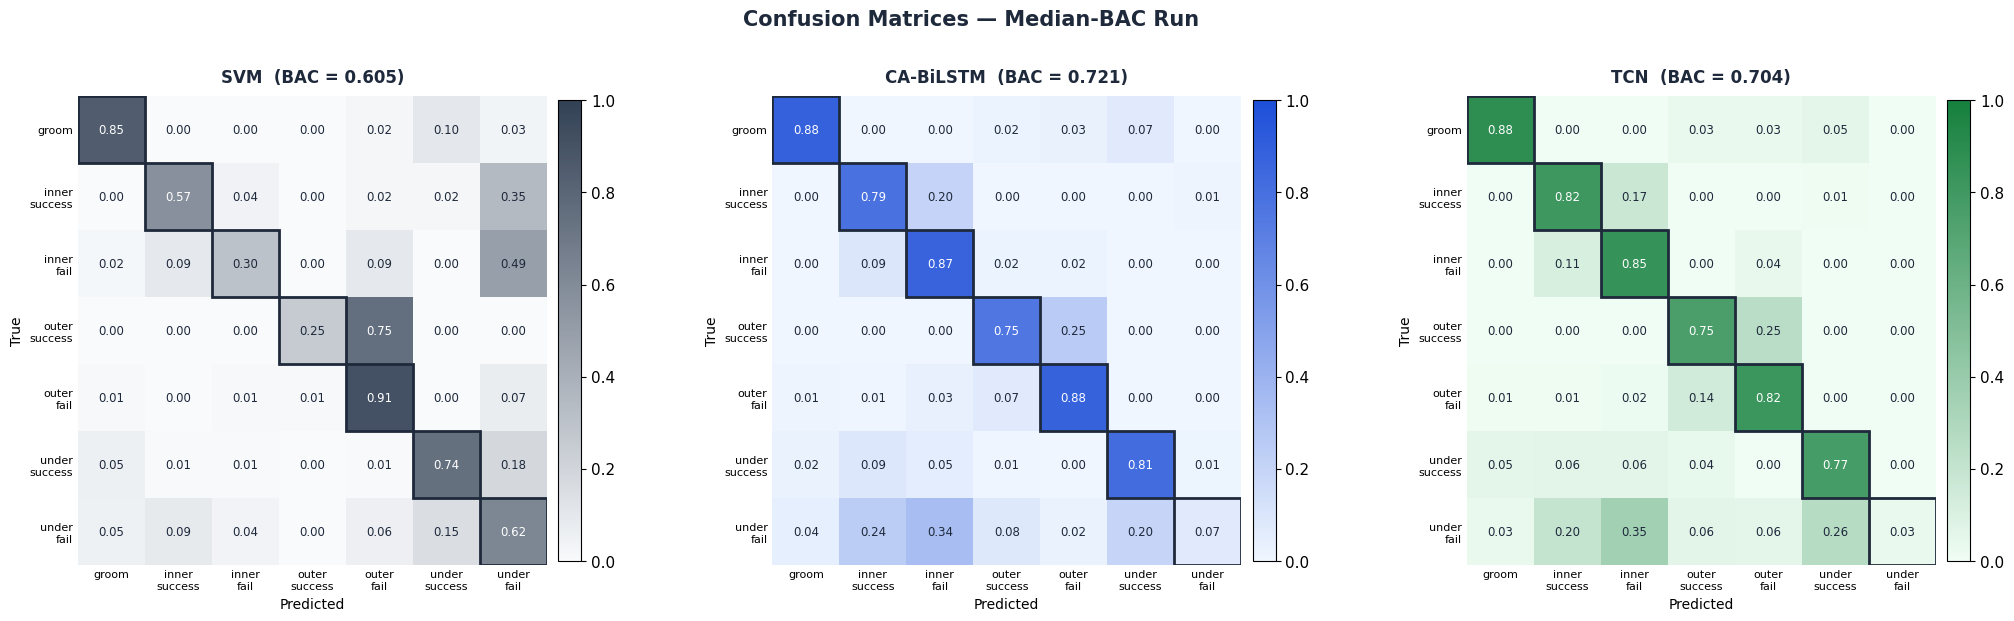

In [30]:
cmap_slate = LinearSegmentedColormap.from_list('sl', ['#F8FAFC', '#334155'])
cmap_blue  = LinearSegmentedColormap.from_list('b',  ['#EFF6FF', '#1D4ED8'])
cmap_green = LinearSegmentedColormap.from_list('g',  ['#F0FDF4', '#15803D'])

svm_med  = pick_median(svm_bacs,  results['svm'])
lstm_med = pick_median(lstm_bacs, results['lstm'])
tcn_med  = pick_median(tcn_bacs,  results['tcn'])

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Confusion Matrices — Median-BAC Run', fontsize=15,
             fontweight='700', color=C_SLATE, y=1.02)

for ax, r, cmap, title in [
    (axes[0], svm_med,  cmap_slate, 'SVM'),
    (axes[1], lstm_med, cmap_blue,  'CA-BiLSTM'),
    (axes[2], tcn_med,  cmap_green, 'TCN'),
]:
    cm   = confusion_matrix(r['test_labels'], r['test_preds'], labels=list(range(N_CLASSES)))
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    im   = ax.imshow(cm_n, cmap=cmap, vmin=0, vmax=1)
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, f'{cm_n[i,j]:.2f}', ha='center', va='center',
                    fontsize=8.5, fontweight='500',
                    color='white' if cm_n[i,j]>0.5 else C_SLATE)
        ax.add_patch(mpatches.Rectangle((i-.5, i-.5), 1, 1, lw=2, edgecolor=C_SLATE, facecolor='none'))
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(SHORT_NAMES, fontsize=8); ax.set_yticklabels(SHORT_NAMES, fontsize=8)
    ax.set_xlabel('Predicted', fontsize=10); ax.set_ylabel('True', fontsize=10)
    ax.set_title(f'{title}  (BAC = {r["test_bac"]:.3f})', fontsize=12, pad=10, color=C_SLATE)
    ax.tick_params(length=0)
    for sp in ax.spines.values(): sp.set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(SDIR, 'fig6_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()


## Final Comparison Table

In [31]:
print('\n' + '='*90)
print(f'  Final Comparison Table   ({len(SEEDS)} seeds: {SEEDS})')
print('='*90)

cols   = ['Metric', 'SVM', 'CA-BiLSTM', 'TCN', 'TCN vs LSTM']
widths = [32, 18, 18, 18, 18]
print(''.join(c.ljust(w) for c, w in zip(cols, widths)))
print('-'*90)

def row(label, svm_v, lstm_v, tcn_v, delta=''):
    vals = [label, svm_v, lstm_v, tcn_v, delta]
    print(''.join(str(v).ljust(w) for v, w in zip(vals, widths)))

row('Test BAC (mean)',
    f'{svm_bacs.mean():.4f}', f'{lstm_bacs.mean():.4f}', f'{tcn_bacs.mean():.4f}',
    f'{diff.mean():+.4f}')
row('Test BAC (std)',
    f'{svm_bacs.std():.4f}',  f'{lstm_bacs.std():.4f}',  f'{tcn_bacs.std():.4f}')
row('Test BAC (max)',
    f'{svm_bacs.max():.4f}',  f'{lstm_bacs.max():.4f}',  f'{tcn_bacs.max():.4f}')
row('Test Accuracy (mean)',
    f'{np.mean([r["test_acc"] for r in results["svm"]]):.4f}',
    f'{np.mean([r["test_acc"] for r in results["lstm"]]):.4f}',
    f'{np.mean([r["test_acc"] for r in results["tcn"]]):.4f}')
row('Trainable Parameters',
    'N/A (kernel)', f'{LSTM_PARAMS:,}', f'{TCN_PARAMS:,}',
    f'{TCN_PARAMS/LSTM_PARAMS:.2f}× LSTM')
row('BAC per 1k Params',
    'N/A',
    f'{lstm_bacs.mean()/(LSTM_PARAMS/1000):.5f}',
    f'{tcn_bacs.mean()/(TCN_PARAMS/1000):.5f}')
row('Train Time (mean, s)',
    f'{svm_times.mean():.1f}', f'{lstm_times.mean():.1f}', f'{tcn_times.mean():.1f}')
row('Inference Latency (ms/sample)',
    f'{svm_inf.mean():.3f}', f'{lstm_inf.mean():.3f}', f'{tcn_inf.mean():.3f}')
row('Best Epoch (mean ± std)',
    'N/A',
    f'{lstm_best_eps.mean():.1f} ± {lstm_best_eps.std():.1f}',
    f'{tcn_best_eps.mean():.1f}  ± {tcn_best_eps.std():.1f}',
    f'{tcn_best_eps.mean()-lstm_best_eps.mean():+.1f} ep')
row('Parallelisable (Conv)',    'No',   'No',   'Yes')
row('Auxiliary position task',  'No',   'No',   'Yes')
row('Receptive field (bins)',    'All',  'All',
    str(1 + 2*(CONFIG["tcn_k"]-1)*(2**len(CONFIG["tcn_channels"]) - 1)))

print('-'*90)
print(f'Bootstrap 95% CI  mean(TCN − LSTM) : [{ci_low:+.4f},  {ci_high:+.4f}]')
sig_str = '  *significant*' if p_one < 0.05 else '  (not significant)'
print(f'Paired t-test p (one-sided, TCN > LSTM) : {p_one:.4f}{sig_str}')
print('='*90)



  Final Comparison Table   (5 seeds: [42, 7, 123, 2024, 999])
Metric                          SVM               CA-BiLSTM         TCN               TCN vs LSTM       
------------------------------------------------------------------------------------------
Test BAC (mean)                 0.6113            0.7200            0.7114            -0.0086           
Test BAC (std)                  0.0172            0.0260            0.0150                              
Test BAC (max)                  0.6338            0.7553            0.7385                              
Test Accuracy (mean)            0.7185            0.4871            0.4659                              
Trainable Parameters            N/A (kernel)      539,728           430,373           0.80× LSTM        
BAC per 1k Params               N/A               0.00133           0.00165                             
Train Time (mean, s)            9.9               91.6              270.4                               
Infere

## Cross-Session Generalization Benchmark

Evaluates all three models with **session-disjoint** splits (train/val/test from different sessions).


In [32]:
all_sessions = get_all_session_ids(MAT_PATHS)
print(f"Found {len(all_sessions)} sessions across all files.")

if CONFIG['cross_session_max_folds'] is None:
    fold_ids = list(range(len(all_sessions)))
else:
    fold_ids = list(range(min(int(CONFIG['cross_session_max_folds']), len(all_sessions))))

cs_results = {'svm': [], 'lstm': [], 'tcn': []}

for fold_id in fold_ids:
    seed = 10_000 + fold_id
    sep = '─' * 70
    print(f'\n{sep}')
    print(f"  Cross-session fold {fold_id+1}/{len(fold_ids)}  (seed = {seed})")
    print(f"{sep}")

    X9, X10, y, idx_train, idx_val, idx_test, cw, pcw, meta = build_arrays(
        MAT_PATHS, seed=seed, split_mode='cross_session', session_holdout=fold_id, return_meta=True)

    n_test_classes = np.unique(y[idx_test]).size
    if n_test_classes < 2:
        print(f"  Skipping fold: holdout has only {n_test_classes} class.")
        continue

    print(f"  Test session: {meta['test_session']}")
    print('  [1/3]  SVM')
    r = train_svm(seed, X9, y, idx_train, idx_test)
    r['heldout_session'] = meta['test_session']
    cs_results['svm'].append(r)
    print(f"         BAC = {r['test_bac']:.4f}")

    print('  [2/3]  CA-BiLSTM')
    r = train_lstm(seed, X9, y, idx_train, idx_val, idx_test, cw)
    r['heldout_session'] = meta['test_session']
    cs_results['lstm'].append(r)
    print(f"         BAC = {r['test_bac']:.4f}   best epoch = {r['best_epoch']}")

    print('  [3/3]  TCN')
    r = train_tcn(seed, X10, y, idx_train, idx_val, idx_test, cw, pcw)
    r['heldout_session'] = meta['test_session']
    cs_results['tcn'].append(r)
    print(f"         BAC = {r['test_bac']:.4f}   best epoch = {r['best_epoch']}")

np.save(os.path.join(CONFIG['save_dir'], 'cross_session_results.npy'), cs_results, allow_pickle=True)
print('\nCross-session benchmark complete.')


Found 8 sessions across all files.

──────────────────────────────────────────────────────────────────────
  Cross-session fold 1/8  (seed = 10000)
──────────────────────────────────────────────────────────────────────
Loading data...
  3 session(s) found in 1D_1.mat
  5 session(s) found in 1D_2.mat
  Split mode: cross_session
  Holdout session: 1D_1.mat::Ab
  Validation session: 1D_1.mat::Cb
  Total: 14,002 licks  —  train: 9,937  |  val: 1,518  |  test: 2,547
  Test session: 1D_1.mat::Ab
  [1/3]  SVM
         BAC = 0.4810
  [2/3]  CA-BiLSTM
         BAC = 0.5238   best epoch = 8
  [3/3]  TCN
         BAC = 0.5370   best epoch = 32

──────────────────────────────────────────────────────────────────────
  Cross-session fold 2/8  (seed = 10001)
──────────────────────────────────────────────────────────────────────
Loading data...
  3 session(s) found in 1D_1.mat
  5 session(s) found in 1D_2.mat
  Split mode: cross_session
  Holdout session: 1D_1.mat::Bb
  Validation session: 1D_2.mat::A

In [33]:
if len(cs_results['svm']) == 0:
    print('No valid cross-session folds were completed.')
else:
    cs_svm_bacs  = np.array([r['test_bac'] for r in cs_results['svm']])
    cs_lstm_bacs = np.array([r['test_bac'] for r in cs_results['lstm']])
    cs_tcn_bacs  = np.array([r['test_bac'] for r in cs_results['tcn']])

    print('\n' + '─'*78)
    print(f"Cross-session summary over {len(cs_tcn_bacs)} held-out sessions")
    print('─'*78)
    print(f"SVM       : {cs_svm_bacs.mean():.4f} ± {cs_svm_bacs.std():.4f}")
    print(f"CA-BiLSTM : {cs_lstm_bacs.mean():.4f} ± {cs_lstm_bacs.std():.4f}")
    print(f"TCN       : {cs_tcn_bacs.mean():.4f} ± {cs_tcn_bacs.std():.4f}")

    print('\nPaired one-sided tests (cross-session):')
    for nm, a, b in [
        ('TCN > CA-BiLSTM', cs_tcn_bacs, cs_lstm_bacs),
        ('CA-BiLSTM > SVM', cs_lstm_bacs, cs_svm_bacs),
        ('TCN > SVM', cs_tcn_bacs, cs_svm_bacs),
    ]:
        t_, p_two = stats.ttest_rel(a, b)
        p_one = p_two / 2 if t_ >= 0 else 1 - p_two / 2
        print(f"  {nm:<17}  t = {t_:>7.3f}   p(one-sided) = {p_one:.4f}")



──────────────────────────────────────────────────────────────────────────────
Cross-session summary over 8 held-out sessions
──────────────────────────────────────────────────────────────────────────────
SVM       : 0.5156 ± 0.0382
CA-BiLSTM : 0.6276 ± 0.0783
TCN       : 0.6497 ± 0.0814

Paired one-sided tests (cross-session):
  TCN > CA-BiLSTM    t =   1.688   p(one-sided) = 0.0676
  CA-BiLSTM > SVM    t =   3.542   p(one-sided) = 0.0047
  TCN > SVM          t =   3.850   p(one-sided) = 0.0031


## Additional Diagnostics — Architecture Ceiling vs Sparse-Data Ceiling

This section adds controlled post-training experiments to determine whether the current decoding ceiling is mainly due to model architecture or sparse neural input constraints.

1. Same split/seed protocol across **CA-BiLSTM, CA-BiGRU, TCN, and Micro-ViT**.
2. Test-time spike sparsity stress test (masking only neural spike channels; kinematic channels are untouched).
3. Quantitative comparison of architecture spread vs sparsity-induced drop.
4. Gradient-based interpretability maps and summary diagrams.


In [34]:
# Diagnostic helpers (kept separate from the main training cells)

def _diag_sched_for_epochs(opt, epochs, eta_min=1e-6):
    if epochs <= 5:
        return CosineAnnealingLR(opt, max(1, epochs), eta_min=eta_min)
    warmup = LinearLR(opt, start_factor=0.1, end_factor=1.0, total_iters=5)
    cosine = CosineAnnealingLR(opt, epochs - 5, eta_min=eta_min)
    return SequentialLR(opt, schedulers=[warmup, cosine], milestones=[5])

def diag_train_rnn_with_model(arch, seed, X9, y, idx_train, idx_val, idx_test, cw, epochs):
    assert arch in ('lstm', 'bigru')
    set_seed(seed)
    tr_ld, va_ld, te_ld = make_loaders_lstm(X9, y, idx_train, idx_val, idx_test)

    if arch == 'lstm':
        model = CABiLSTM(9, CONFIG['lstm_hidden'], CONFIG['lstm_layers'],
                        N_CLASSES, CONFIG['lstm_dropout'],
                        CONFIG['lstm_ca_reduction']).to(device)
    else:
        model = CABiGRU(9, CONFIG['lstm_hidden'], CONFIG['lstm_layers'],
                       N_CLASSES, CONFIG['lstm_dropout'],
                       CONFIG['lstm_ca_reduction']).to(device)

    crit = nn.CrossEntropyLoss(
        weight=cw.to(device) if CONFIG['use_class_weights'] else None,
        label_smoothing=0.05
    )
    opt = AdamW(model.parameters(), lr=CONFIG['lstm_lr'], weight_decay=CONFIG['lstm_wd'])
    sched = _diag_sched_for_epochs(opt, epochs, eta_min=1e-6)

    best_bac, best_ep, best_state = -1.0, 0, None
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in tr_ld:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
            opt.step()
        sched.step()

        _, _, va_bac, _, _ = _eval_lstm(model, va_ld, crit)
        if va_bac > best_bac:
            best_bac = va_bac
            best_ep = ep
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    _, te_acc, te_bac, te_preds, te_labels = _eval_lstm(model, te_ld, crit)
    return model, {
        'test_bac': te_bac,
        'test_acc': te_acc,
        'test_preds': te_preds,
        'test_labels': te_labels,
        'best_epoch': best_ep,
    }

def diag_train_vit_with_model(seed, X9, y, idx_train, idx_val, idx_test, cw, epochs):
    set_seed(seed)
    tr_ld, va_ld, te_ld = make_loaders_vit(X9, y, idx_train, idx_val, idx_test)

    model = MicroViT(**CONFIG_VIT).to(device)
    crit = nn.CrossEntropyLoss(
        weight=cw.to(device) if CONFIG['use_class_weights'] else None,
        label_smoothing=0.05
    )
    opt = AdamW(model.parameters(), lr=CONFIG['lstm_lr'], weight_decay=CONFIG['lstm_wd'])
    sched = _diag_sched_for_epochs(opt, epochs, eta_min=1e-6)

    best_bac, best_ep, best_state = -1.0, 0, None
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in tr_ld:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
            opt.step()
        sched.step()

        _, _, va_bac, _, _ = _eval_lstm(model, va_ld, crit)
        if va_bac > best_bac:
            best_bac = va_bac
            best_ep = ep
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    _, te_acc, te_bac, te_preds, te_labels = _eval_lstm(model, te_ld, crit)
    return model, {
        'test_bac': te_bac,
        'test_acc': te_acc,
        'test_preds': te_preds,
        'test_labels': te_labels,
        'best_epoch': best_ep,
    }

def diag_train_tcn_with_model(seed, X10, y, idx_train, idx_val, idx_test, cw, pcw, epochs):
    set_seed(seed)
    tr_ld, va_ld, te_ld = make_loaders_tcn(X10, y, idx_train, idx_val, idx_test)

    base_model = TCNClassifier(10, CONFIG['tcn_channels'], CONFIG['tcn_k'],
                               CONFIG['tcn_drop'], CONFIG['tcn_type_embed'],
                               CONFIG['tcn_cond_dim'], N_CLASSES,
                               CONFIG['tcn_local_k'],
                               use_bottleneck=CONFIG['tcn_use_bottleneck'],
                               bottleneck_ratio=CONFIG['tcn_bottleneck_ratio'],
                               attn_heads=CONFIG['tcn_attn_heads'],
                               attn_drop=CONFIG['tcn_attn_drop']).to(device)
    model = maybe_parallelize_tcn(base_model)

    c7 = nn.CrossEntropyLoss(weight=cw.to(device) if CONFIG['use_class_weights'] else None,
                         label_smoothing=0.05)
    c_pos = nn.CrossEntropyLoss(weight=pcw.to(device) if CONFIG['use_class_weights'] else None)
    opt = AdamW(build_tcn_param_groups(base_model, CONFIG['tcn_lr'], CONFIG['tcn_wd'], lr_decay=CONFIG['tcn_llrd']))
    sched = _diag_sched_for_epochs(opt, epochs, eta_min=1e-5)

    best_bac, best_ep, best_state = -1.0, 0, None
    for ep in range(1, epochs + 1):
        model.train()
        for xb, y7b, ypos in tr_ld:
            xb, y7b, ypos = xb.to(device), y7b.to(device), ypos.to(device)
            lg7, lgp, _ = model(xb)
            loss = c7(lg7, y7b) + CONFIG['tcn_aux_pos_weight'] * c_pos(lgp, ypos)
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(base_model.parameters(), CONFIG['grad_clip'])
            opt.step()
        sched.step()

        model.eval()
        p_all, l_all = [], []
        with torch.no_grad():
            for xb, y7b, _ in va_ld:
                p_all.extend(model(xb.to(device))[0].argmax(1).cpu().numpy())
                l_all.extend(y7b.numpy())
        va_bac = balanced_accuracy_score(l_all, p_all)
        if va_bac > best_bac:
            best_bac = va_bac
            best_ep = ep
            best_state = {k: v.detach().cpu().clone() for k, v in base_model.state_dict().items()}

    base_model.load_state_dict(best_state)
    model.eval()
    p_all, l_all = [], []
    with torch.no_grad():
        for xb, y7b, _ in te_ld:
            p_all.extend(model(xb.to(device))[0].argmax(1).cpu().numpy())
            l_all.extend(y7b.numpy())
    te_bac = balanced_accuracy_score(l_all, p_all)
    te_acc = (np.array(p_all) == np.array(l_all)).mean()

    return model, {
        'test_bac': te_bac,
        'test_acc': te_acc,
        'test_preds': np.array(p_all),
        'test_labels': np.array(l_all),
        'best_epoch': best_ep,
    }

@torch.no_grad()
def diag_eval_arch_model(model, arch, X9_eval, X10_eval, y_eval):
    if arch in ('lstm', 'bigru'):
        ld = DataLoader(LickDataset9(X9_eval, y_eval), CONFIG['batch_size'])
        preds, labels = [], []
        model.eval()
        for xb, yb in ld:
            lg = model(xb.to(device))
            preds.extend(lg.argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    elif arch == 'vit':
        ld = DataLoader(LickDatasetViT(X9_eval, y_eval), CONFIG['batch_size'])
        preds, labels = [], []
        model.eval()
        for xb, yb in ld:
            lg = model(xb.to(device))
            preds.extend(lg.argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    elif arch == 'tcn':
        y_pos = LABEL_TO_POSITION[y_eval]
        ld = DataLoader(LickDataset10(X10_eval, y_eval, y_pos, augment=False), CONFIG['batch_size'])
        preds, labels = [], []
        model.eval()
        for xb, yb, _ in ld:
            lg = model(xb.to(device))[0]
            preds.extend(lg.argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    else:
        raise ValueError(f'Unknown architecture: {arch}')

    preds = np.array(preds)
    labels = np.array(labels)
    bac = balanced_accuracy_score(labels, preds)
    acc = (preds == labels).mean()
    return bac, acc, preds, labels

def diag_apply_spike_sparsity(X, keep_ratio, seed=0, spike_dims=4):
    Xp = X.copy()
    if keep_ratio >= 1.0:
        return Xp
    rng = np.random.default_rng(seed)
    m = (rng.random(Xp[..., :spike_dims].shape) < keep_ratio).astype(Xp.dtype)
    Xp[..., :spike_dims] = Xp[..., :spike_dims] * m
    return Xp

def diag_mean_saliency_map(model, arch, X9_eval, X10_eval, y_eval, max_samples=48):
    # Returns mean |grad| map over correctly predicted samples: shape [T=30, spike_ch=4]
    _, _, preds, labels = diag_eval_arch_model(model, arch, X9_eval, X10_eval, y_eval)
    good = np.where(preds == labels)[0]
    if len(good) == 0:
        return np.zeros((N_BINS, 4), dtype=np.float32)

    selected = good[:max_samples]
    grads = []
    was_training = model.training
    model.eval()

    try:
        for j in selected:
            model.zero_grad(set_to_none=True)

            if arch in ('lstm', 'bigru'):
                x = torch.tensor(X9_eval[j:j+1], dtype=torch.float32, device=device, requires_grad=True)  # [1, T, 9]
                # CuDNN RNN kernels on GPU do not support eval-mode backward for saliency.
                with torch.backends.cudnn.flags(enabled=False):
                    logits = model(x)
                    target = logits[0, int(y_eval[j])]
                target.backward()
                g = x.grad.detach().abs().cpu().numpy()[0, :, :4]  # [T, 4]

            elif arch == 'vit':
                x_np = X9_eval[j].T[np.newaxis, ...]  # [1, 9, T]
                x = torch.tensor(x_np, dtype=torch.float32, device=device, requires_grad=True)
                logits = model(x)
                target = logits[0, int(y_eval[j])]
                target.backward()
                g = x.grad.detach().abs().cpu().numpy()[0, :4, :].T  # [T, 4]

            elif arch == 'tcn':
                x_np = X10_eval[j].T[np.newaxis, ...]  # [1, 10, T]
                x = torch.tensor(x_np, dtype=torch.float32, device=device, requires_grad=True)
                logits = model(x)[0]
                target = logits[0, int(y_eval[j])]
                target.backward()
                g = x.grad.detach().abs().cpu().numpy()[0, :4, :].T  # [T, 4]

            else:
                raise ValueError(f'Unknown architecture: {arch}')

            grads.append(g)

        g_mean = np.mean(grads, axis=0).astype(np.float32)
        g_mean /= (g_mean.max() + 1e-8)
        return g_mean
    finally:
        model.train(was_training)

def diag_bootstrap_ci(x, n_boot=4000, alpha=0.05, seed=0):
    x = np.asarray(x, dtype=np.float64)
    if x.size == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    means = []
    for _ in range(n_boot):
        s = rng.choice(x, size=x.size, replace=True)
        means.append(s.mean())
    lo = np.percentile(means, 100 * (alpha / 2))
    hi = np.percentile(means, 100 * (1 - alpha / 2))
    return float(lo), float(hi)


In [35]:
# Controlled architecture-vs-sparsity experiment
DIAG_SEEDS = [42, 7]
DIAG_EPOCHS = min(24, CONFIG['epochs'])   # Increase for tighter estimates
DIAG_KEEP_RATIOS = [1.00, 0.75, 0.50, 0.25]
DIAG_MODELS = ['lstm', 'bigru', 'tcn', 'vit']

diag_records = []
diag_saliency = {m: [] for m in DIAG_MODELS}

for seed in DIAG_SEEDS:
    print('\n' + '─'*82)
    print(f'Diagnostic seed {seed} | epochs/model = {DIAG_EPOCHS}')
    print('─'*82)

    X9, X10, y, idx_train, idx_val, idx_test, cw, pcw = build_arrays(MAT_PATHS, seed=seed)

    X9_test = X9[idx_test]
    X10_test = X10[idx_test]
    y_test = y[idx_test]

    X9_sparse = {}
    X10_sparse = {}
    for keep in DIAG_KEEP_RATIOS:
        s0 = seed * 1000 + int(round(keep * 100))
        X9_sparse[keep] = diag_apply_spike_sparsity(X9_test, keep_ratio=keep, seed=s0, spike_dims=4)
        X10_sparse[keep] = diag_apply_spike_sparsity(X10_test, keep_ratio=keep, seed=s0, spike_dims=4)

    # Train each architecture once on the same split, then evaluate all sparsity levels
    train_plan = [
        ('lstm',  lambda: diag_train_rnn_with_model('lstm', seed, X9, y, idx_train, idx_val, idx_test, cw, DIAG_EPOCHS)),
        ('bigru', lambda: diag_train_rnn_with_model('bigru', seed, X9, y, idx_train, idx_val, idx_test, cw, DIAG_EPOCHS)),
        ('tcn',   lambda: diag_train_tcn_with_model(seed, X10, y, idx_train, idx_val, idx_test, cw, pcw, DIAG_EPOCHS)),
        ('vit',   lambda: diag_train_vit_with_model(seed, X9, y, idx_train, idx_val, idx_test, cw, DIAG_EPOCHS)),
    ]

    for arch, train_fn in train_plan:
        print(f'  Training {arch.upper()} ...')
        model, base_res = train_fn()
        print(f"    Full test BAC = {base_res['test_bac']:.4f} (best epoch {base_res['best_epoch']})")

        for keep in DIAG_KEEP_RATIOS:
            bac, acc, preds, labels = diag_eval_arch_model(
                model, arch, X9_sparse[keep], X10_sparse[keep], y_test
            )
            diag_records.append({
                'seed': seed,
                'arch': arch,
                'keep_ratio': float(keep),
                'bac': float(bac),
                'acc': float(acc),
            })

        smap = diag_mean_saliency_map(model, arch, X9_test, X10_test, y_test, max_samples=48)
        diag_saliency[arch].append(smap)

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    del X9, X10, y, idx_train, idx_val, idx_test, cw, pcw, X9_test, X10_test, y_test, X9_sparse, X10_sparse

print('\nDiagnostic experiment complete.')



──────────────────────────────────────────────────────────────────────────────────
Diagnostic seed 42 | epochs/model = 24
──────────────────────────────────────────────────────────────────────────────────
Loading data...
  3 session(s) found in 1D_1.mat
  5 session(s) found in 1D_2.mat
  Split mode: random
  Total: 14,002 licks  —  train: 9,800  |  val: 2,101  |  test: 2,101
  Training LSTM ...
    Full test BAC = 0.7111 (best epoch 12)
  Training BIGRU ...
    Full test BAC = 0.6874 (best epoch 11)
  Training TCN ...
    Full test BAC = 0.7145 (best epoch 21)
  Training VIT ...
    Full test BAC = 0.7143 (best epoch 10)

──────────────────────────────────────────────────────────────────────────────────
Diagnostic seed 7 | epochs/model = 24
──────────────────────────────────────────────────────────────────────────────────
Loading data...
  3 session(s) found in 1D_1.mat
  5 session(s) found in 1D_2.mat
  Split mode: random
  Total: 14,002 licks  —  train: 9,800  |  val: 2,101  |  test

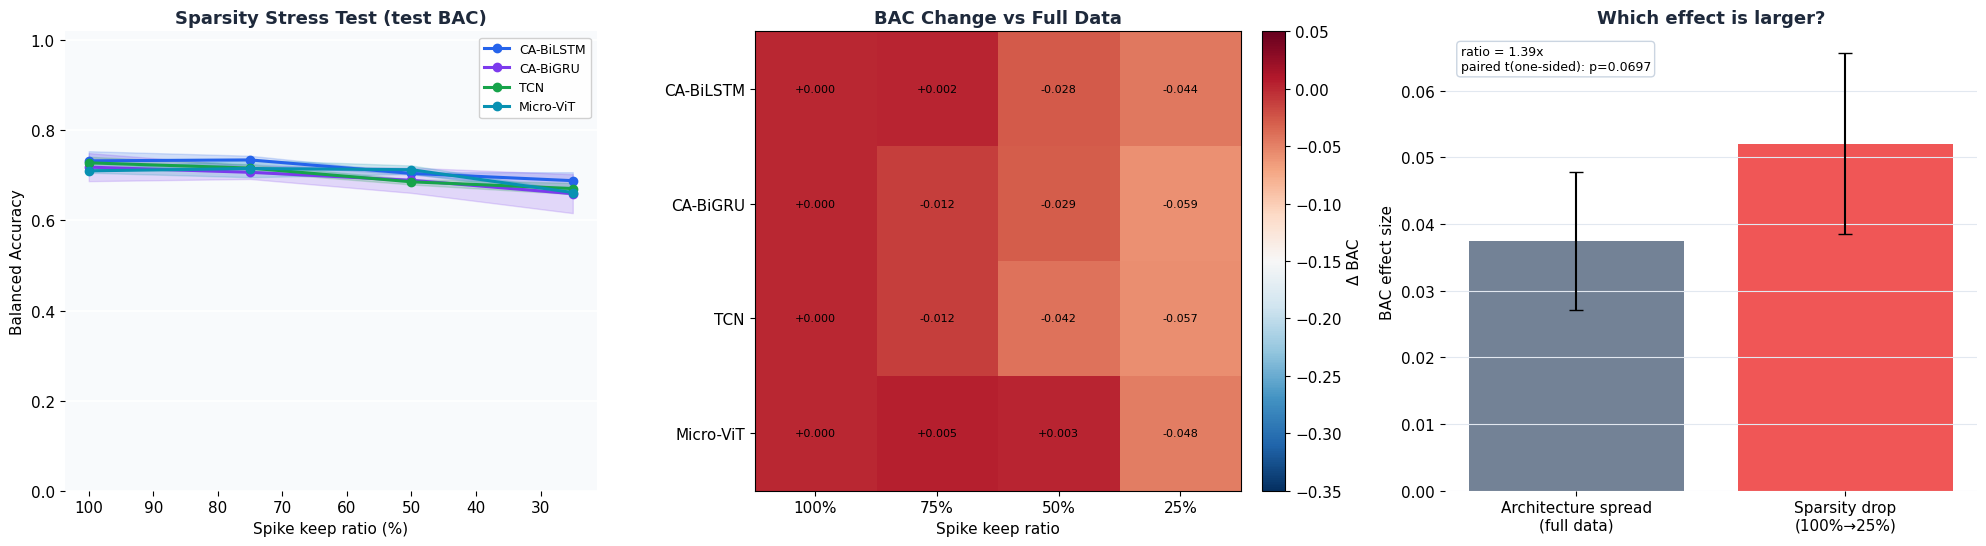

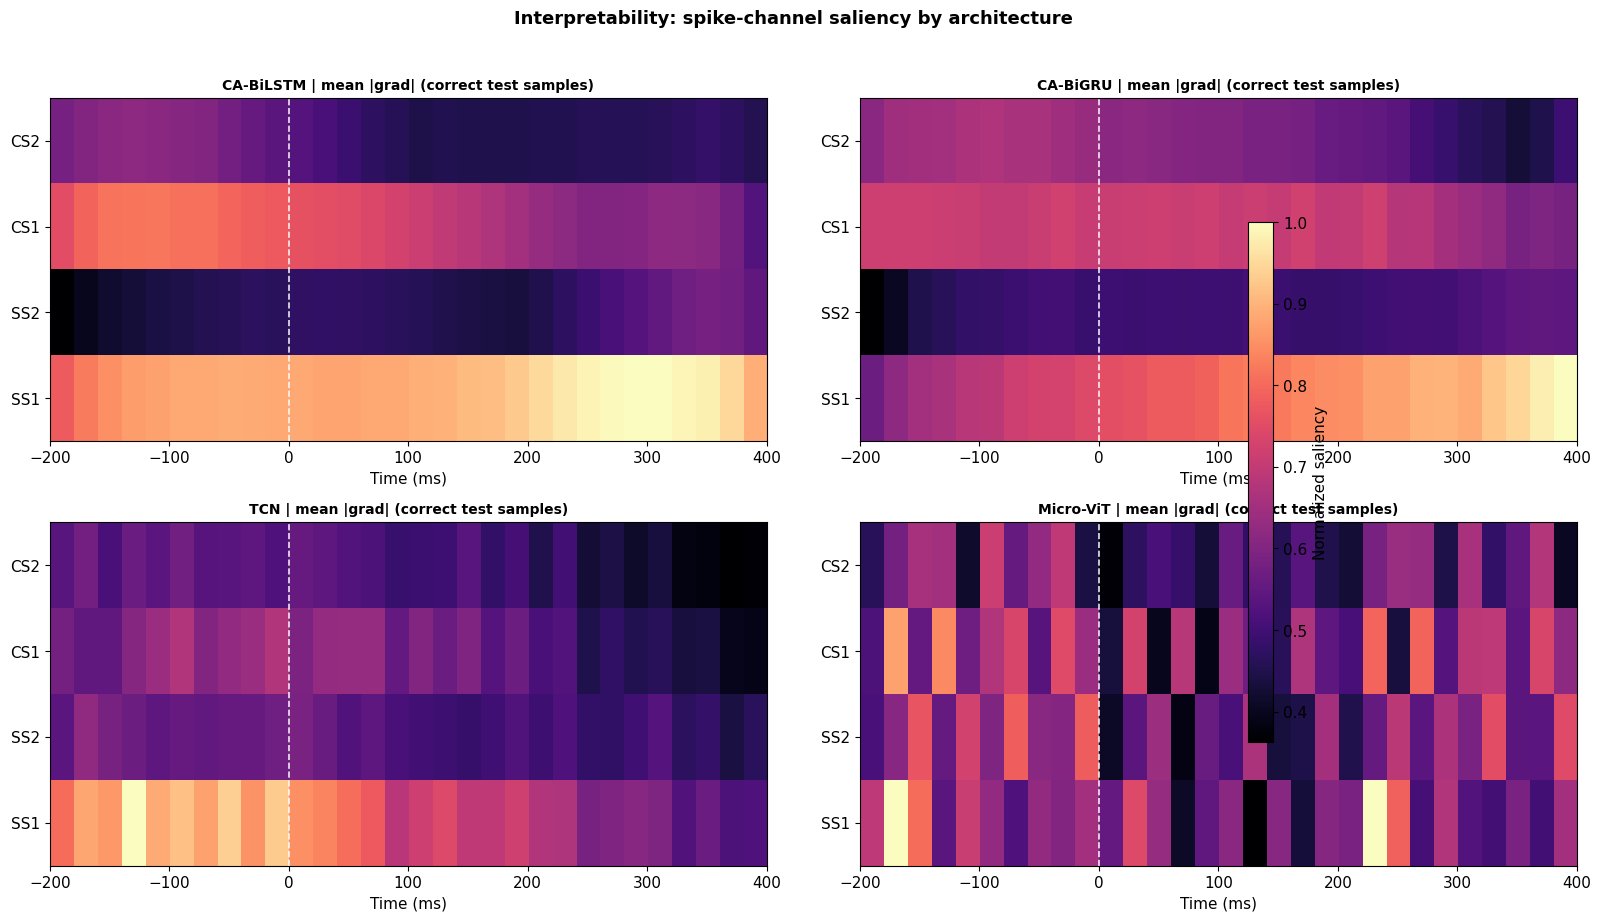


Diagnostic verdict: architecture vs sparse-data limitation
Architecture spread @ full data: 0.0375  (95% CI [0.0271, 0.0478])
Sparsity-induced drop        : 0.0520  (95% CI [0.0384, 0.0656])
Effect ratio (sparsity / architecture): 1.39x
Paired one-sided test p-value: 0.0697
Inferred primary driver: mixed / inconclusive (both contribute)


In [36]:
# Quantitative attribution summary + diagrams
diag_colors = {
    'lstm': globals().get('C_LSTM', '#2563EB'),
    'bigru': globals().get('C_BIGRU', '#7C3AED'),
    'tcn': globals().get('C_TCN', '#16A34A'),
    'vit': globals().get('C_VIT', '#0891B2'),
}
diag_names = {
    'lstm': 'CA-BiLSTM',
    'bigru': 'CA-BiGRU',
    'tcn': 'TCN',
    'vit': 'Micro-ViT',
}

diag_keeps = sorted({r['keep_ratio'] for r in diag_records}, reverse=True)
diag_seed_set = sorted({r['seed'] for r in diag_records})
diag_bac = {(r['seed'], r['arch'], r['keep_ratio']): r['bac'] for r in diag_records}
lowest_keep = min(diag_keeps)

# Architecture spread at full data vs sparsity-induced drop
arch_gap_per_seed = []
sparse_drop_per_seed = []
for s in diag_seed_set:
    full_vals = [diag_bac[(s, m, 1.0)] for m in DIAG_MODELS]
    arch_gap_per_seed.append(max(full_vals) - min(full_vals))

    drops = [diag_bac[(s, m, 1.0)] - diag_bac[(s, m, lowest_keep)] for m in DIAG_MODELS]
    sparse_drop_per_seed.append(float(np.mean(drops)))

arch_gap_per_seed = np.array(arch_gap_per_seed)
sparse_drop_per_seed = np.array(sparse_drop_per_seed)

t_stat, p_two = stats.ttest_rel(sparse_drop_per_seed, arch_gap_per_seed)
p_one = (p_two / 2) if t_stat >= 0 else (1 - p_two / 2)

arch_gap_ci = diag_bootstrap_ci(arch_gap_per_seed, n_boot=5000, seed=11)
sparse_drop_ci = diag_bootstrap_ci(sparse_drop_per_seed, n_boot=5000, seed=13)

arch_gap_mean = float(arch_gap_per_seed.mean())
sparse_drop_mean = float(sparse_drop_per_seed.mean())
ratio = sparse_drop_mean / (arch_gap_mean + 1e-8)

if (sparse_drop_mean > arch_gap_mean) and (p_one < 0.05):
    diag_driver = 'b) sparse neural data constraints dominate'
elif (arch_gap_mean > sparse_drop_mean) and (p_one > 0.95):
    diag_driver = 'a) architecture design dominates'
else:
    diag_driver = 'mixed / inconclusive (both contribute)'

# Prepare BAC curves
curve_stats = {}
for m in DIAG_MODELS:
    means, stds = [], []
    for k in diag_keeps:
        vals = [diag_bac[(s, m, k)] for s in diag_seed_set]
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    curve_stats[m] = (np.array(means), np.array(stds))

# Drop matrix: BAC drop from full-data baseline
drop_mat = np.zeros((len(DIAG_MODELS), len(diag_keeps)), dtype=np.float32)
for i, m in enumerate(DIAG_MODELS):
    full_mean = curve_stats[m][0][diag_keeps.index(1.0)]
    for j, k in enumerate(diag_keeps):
        drop_mat[i, j] = curve_stats[m][0][j] - full_mean

fig, axes = plt.subplots(1, 3, figsize=(20, 5.6))

# (1) BAC vs sparsity
ax = axes[0]
ax.set_facecolor('#F8FAFC')
x = np.array(diag_keeps) * 100
for m in DIAG_MODELS:
    mu, sd = curve_stats[m]
    ax.plot(x, mu, marker='o', lw=2.2, color=diag_colors[m], label=diag_names[m])
    ax.fill_between(x, mu - sd, mu + sd, color=diag_colors[m], alpha=0.18)
ax.set_title('Sparsity Stress Test (test BAC)', color=globals().get('C_SLATE', '#1E293B'))
ax.set_xlabel('Spike keep ratio (%)')
ax.set_ylabel('Balanced Accuracy')
ax.set_ylim(0, 1.02)
ax.invert_xaxis()
ax.grid(True, axis='y', color='white', lw=1.2)
ax.legend(fontsize=9, framealpha=0.9)
for sp in ax.spines.values():
    sp.set_visible(False)

# (2) Drop heatmap
ax = axes[1]
im = ax.imshow(drop_mat, cmap='RdBu_r', aspect='auto', vmin=-0.35, vmax=0.05)
ax.set_title('BAC Change vs Full Data', color=globals().get('C_SLATE', '#1E293B'))
ax.set_xticks(np.arange(len(diag_keeps)))
ax.set_xticklabels([f'{int(k*100)}%' for k in diag_keeps])
ax.set_yticks(np.arange(len(DIAG_MODELS)))
ax.set_yticklabels([diag_names[m] for m in DIAG_MODELS])
ax.set_xlabel('Spike keep ratio')
for i in range(drop_mat.shape[0]):
    for j in range(drop_mat.shape[1]):
        v = drop_mat[i, j]
        ax.text(j, i, f'{v:+.3f}', ha='center', va='center', fontsize=8, color='black')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Δ BAC')

# (3) Effect-size comparison
ax = axes[2]
means = [arch_gap_mean, sparse_drop_mean]
errs_lo = [arch_gap_mean - arch_gap_ci[0], sparse_drop_mean - sparse_drop_ci[0]]
errs_hi = [arch_gap_ci[1] - arch_gap_mean, sparse_drop_ci[1] - sparse_drop_mean]
ax.bar([0, 1], means, yerr=np.array([errs_lo, errs_hi]),
       color=['#64748B', '#EF4444'], alpha=0.9, capsize=5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Architecture spread\n(full data)',
                    f'Sparsity drop\n(100%→{int(lowest_keep*100)}%)'])
ax.set_ylabel('BAC effect size')
ax.set_title('Which effect is larger?', color=globals().get('C_SLATE', '#1E293B'))
ax.grid(True, axis='y', color='#E2E8F0')
for sp in ax.spines.values():
    sp.set_visible(False)
ax.text(0.03, 0.97,
        f'ratio = {ratio:.2f}x\npaired t(one-sided): p={p_one:.4f}',
        transform=ax.transAxes, ha='left', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#CBD5E1'))

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['save_dir'], 'fig_diag_arch_vs_sparsity.png'), dpi=160, bbox_inches='tight')
plt.show()

# Saliency figure
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()
t_ms = np.linspace(-WINDOW_PRE * 1000, WINDOW_POST * 1000, N_BINS)
spike_labels = ['SS1', 'SS2', 'CS1', 'CS2']

for i, m in enumerate(DIAG_MODELS):
    ax = axes[i]
    maps = diag_saliency[m]
    if len(maps) == 0:
        S = np.zeros((N_BINS, 4), dtype=np.float32)
    else:
        S = np.mean(np.stack(maps, axis=0), axis=0)
    S = S / (S.max() + 1e-8)

    im = ax.imshow(S.T, aspect='auto', origin='lower', cmap='magma',
                   extent=[t_ms[0], t_ms[-1], -0.5, 3.5])
    ax.axvline(0, color='white', lw=1.2, ls='--', alpha=0.9)
    ax.set_title(f'{diag_names[m]} | mean |grad| (correct test samples)', fontsize=10)
    ax.set_xlabel('Time (ms)')
    ax.set_yticks(range(4))
    ax.set_yticklabels(spike_labels)

fig.suptitle('Interpretability: spike-channel saliency by architecture',
             fontsize=13, fontweight='bold', y=1.02)
fig.colorbar(im, ax=axes.tolist(), shrink=0.75, label='Normalized saliency')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['save_dir'], 'fig_diag_saliency_maps.png'), dpi=160, bbox_inches='tight')
plt.show()

print('\n' + '='*92)
print('Diagnostic verdict: architecture vs sparse-data limitation')
print('='*92)
print(f'Architecture spread @ full data: {arch_gap_mean:.4f}  (95% CI [{arch_gap_ci[0]:.4f}, {arch_gap_ci[1]:.4f}])')
print(f'Sparsity-induced drop        : {sparse_drop_mean:.4f}  (95% CI [{sparse_drop_ci[0]:.4f}, {sparse_drop_ci[1]:.4f}])')
print(f'Effect ratio (sparsity / architecture): {ratio:.2f}x')
print(f'Paired one-sided test p-value: {p_one:.4f}')
print(f'Inferred primary driver: {diag_driver}')
print('='*92)
